In [1]:
import numpy as np

def impseq(n0,n1,n2):
    
    #      Generates x(n) = delta(n-n0); n1 <= n <= n2
    #      ----------------------------------------------
    #      [x,n] = impseq(n0,n1,n2)
    #     
        
    n=np.array(range(n1,n2+1))
    x = n-n0
    for i in range(len(x)):
        if x[i]!=0: x[i]=0
        else: x[i]=1
    #x = (n-n0) == 0
    return [x,n]

def stepseq(n0,n1,n2):
    #     Generates x(n) = u(n-n0); n1 <= n <= n2
    #     ------------------------------------------
    #     [x,n] = stepseq(n0,n1,n2)
    #
    n=np.arange(n1,n2+1)
    x = n-n0
    for i in range(len(x)):
        if x[i]<0: x[i]=0
        else: x[i]=1
    #x = [(n-n0) >= 0]
    return [x,n]

def  sigadd(x1,n1,x2,n2):
    # % implements y(n) = x1(n)+x2(n)
    # % -----------------------------
    # % [y,n] = sigadd(x1,n1,x2,n2)
    # % y = sum sequence over n, which includes n1 and n2
    # % x1 = first sequence over n1
    # % x2 = second sequence over n2 (n2 can be different from n1)
    # %
    n = np.arange(min(n1.min(0),n2.min(0)),max(n1.max(0),n2.max(0))+1) # duration of y(n)
    y1 = np.zeros((1,len(n)))  #initialization
    y1=y1[0,:]
    y2 = y1.copy()
    y1[np.nonzero(np.logical_and((n>=n1.min(0)),(n<=n1.max(0)))==1)]=x1.copy()
    y2[np.nonzero(np.logical_and((n>=n2.min(0)),(n<=n2.max(0)))==1)]=x2.copy()
    y = y1+y2;
    return [y,n]


def  sigmult(x1,n1,x2,n2):
    # % implements y(n) = x1(n)*x2(n)
    # % -----------------------------
    # % [y,n] = sigmult(x1,n1,x2,n2)
    # % y = product sequence over n, which includes n1 and n2
    # % x1 = first sequence over n1
    # %
    n = np.arange(min(n1.min(0),n2.min(0)),max(n1.max(0),n2.max(0))+1) # duration of y(n)
    y1 = np.zeros((1,len(n)))  #initialization
    y1=y1[0,:]
    y2 = y1.copy()
    y1[np.nonzero(np.logical_and((n>=n1.min(0)),(n<=n1.max(0)))==1)]=x1.copy()
    y2[np.nonzero(np.logical_and((n>=n2.min(0)),(n<=n2.max(0)))==1)]=x2.copy()
    y = y1*y2
    return [y,n]


def sigshift(x,m,k):
    # % implements y(n) = x(n-k)
    # % -------------------------
    # % [y,n] = sigshift(x,m,k)
    # %
    n = m+k
    y = x.copy()
    return [y,n]


def sigfold(x,n):
    # % implements y(n) = x(-n)
    # % -----------------------
    # % [y,n] = sigfold(x,n)
    # %
    y = np.flip(x)
    n = -np.flip(n)
    return [y,n]

def conv_m(x,nx,h,nh):
    # Modified convolution routine for signal processing
    # --------------------------------------------------
    # [y,ny] = conv_m(x,nx,h,nh)
    # [y,ny] = convolution result
    # [x,nx] = first signal
    # [h,nh] = second signal
    # 
    nyb = nx[0]+nh[0]
    nye = nx[len(x)-1] + nh[len(h)-1]
    ny = np.arange(nyb,nye+1)
    y = np.convolve(x,h)
    return [y,ny]

In [2]:
# funções para filtros analógicos e digitais

import numpy as np
from scipy import signal

def u_buttap(N,Omegac):
    # Unnormalized Butterworth Analog Lowpass Filter Prototype
    # --------------------------------------------------------
    # [b,a] = u_buttap(N,Omegac);
    # b = numerator polynomial coefficients of Ha(s)
    # a = denominator polynomial coefficients of Ha(s)
    # N = Order of the Butterworth Filter
    # Omegac = Cutoff frequency in radians/sec
    [z,p,k] = signal.buttap(N)
    p = p*Omegac
    k = k*Omegac**N
    B = np.real(np.poly(z))
    b0 = k
    b = k*B
    if type(b)!=np.ndarray: b=np.array([b])
    a = np.real(np.poly(p))
    if type(a)!=np.ndarray: a=np.array([a])
    return [b,a]

def u_chb1ap(N,Rp,Omegac):
    # Unnormalized Chebyshev-1 Analog Lowpass Filter Prototype
    # --------------------------------------------------------
    # [b,a] = u_chb1ap(N,Rp,Omegac)
    # b = numerator polynomial coefficients of Ha(s)
    # a = denominator polynomial coefficients of Ha(s)
    # N = Order of the Elliptic Filter
    # Rp = Passband Ripple in dB; Rp > 0
    # Omegac = Cutoff frequency in radians/sec
    [z,p,k] = signal.cheb1ap(N,Rp)
    a = np.real(np.poly(p))
    aNn = a[int(N)]
    p = p*Omegac
    a = np.real(np.poly(p))
    aNu = a[int(N)]  
    k = k*aNu/aNn
    b0 = k
    B = np.real(np.poly(z))
    b = k*B
    if type(b)!=np.ndarray: b=np.array([b])
    a = np.real(np.poly(p))
    if type(a)!=np.ndarray: a=np.array([a])
    return [b,a]

def afd_butt(Wp,Ws,Rp,As):
    # Analog Lowpass Filter Design: Butterworth
    #  -----------------------------------------
    #  [b,a] = afd_butt(Wp,Ws,Rp,As);
    #   b = Numerator coefficients of Ha(s)
    #   a = Denominator coefficients of Ha(s)
    #  Wp = Passband edge frequency in rad/sec; Wp > 0
    #  Ws = Stopband edge frequency in rad/sec; Ws > Wp > 0
    # Rp = Passband ripple in +dB; (Rp > 0)
    # As = Stopband attenuation in +dB; (As > 0)
    #
    if Wp <= 0:
        print("error: Passband edge must be larger than 0")
    if Ws <= Wp:
        print("error: Stopband edge must be larger than Passband edge")
    if (Rp <= 0) or (As < 0):
        print("error: PB ripple and/or SB attenuation ust be larger than 0")
    N = np.ceil((np.log10((10**(Rp/10)-1)/(10**(As/10)-1)))/(2*np.log10(Wp/Ws)))
    print("\n*** Butterworth Filter Order =",int(N))
    OmegaC = Wp/((10**(Rp/10)-1)**(1/(2*N)))
    [b,a] = u_buttap(N,OmegaC)
    return b,a

def afd_chb1(Wp,Ws,Rp,As):
    # Analog Lowpass Filter Design: Chebyshev-1
    #  -----------------------------------------
    #  [b,a] = afd_chb1(Wp,Ws,Rp,As);
    #   b = Numerator coefficients of Ha(s)
    #   a = Denominator coefficients of Ha(s)
    #  Wp = Passband edge frequency in rad/sec; Wp > 0
    #  Ws = Stopband edge frequency in rad/sec; Ws > Wp > 0
    # Rp = Passband ripple in +dB; (Rp > 0)
    # As = Stopband attenuation in +dB; (As > 0)
    #
    if Wp <= 0:
        print("error: Passband edge must be larger than 0")
    if Ws <= Wp:
        print("error: Stopband edge must be larger than Passband edge")
    if (Rp <= 0) or (As < 0):
        print("error: PB ripple and/or SB attenuation ust be larger than 0")
    ep = np.sqrt(10**(Rp/10)-1)
    A = 10**(As/20)
    OmegaC = Wp
    OmegaR = Ws/Wp
    g = np.sqrt(A*A-1)/ep
    N = np.ceil(np.log10(g+np.sqrt(g*g-1))/np.log10(OmegaR+np.sqrt(OmegaR*OmegaR-1)))
    print("\n*** Chebyshev-1 Filter Order =",int(N))
    [b,a]=u_chb1ap(N,Rp,OmegaC)
    return b,a


def freqs_m(b,a,wmax):
    # Computation of s-domain frequency response: Modified version
    # ------------------------------------------------------------
    # [db,mag,pha,w] = freqs_m(b,a,wmax);
    #   db = Relative magnitude in db over [0 to wmax]
    #  mag = Absolute magnitude over [0 to wmax]
    #  pha = Phase response in radians over [0 to wmax]
    #    w = array of 500 frequency samples between [0 to wmax]
    #    b = Numerator polynomial coefficents of Ha(s)
    #    a = Denominator polynomial coefficents of Ha(s)
    # wmax = Maximum frequency in rad/sec over which response is desired
    #
    #w = np.arange(501)*wmax/500
    w,H = signal.freqs(b,a,worN=501)
    mag = np.abs(H)
    db = 20*np.log10((mag+np.spacing(1))/np.max(mag))
    pha = np.angle(H)
    return db,mag,pha,w

def imp_invr(c,d,T):
    # Impulse Invariance Transformation from Analog to Digital Filter
    # ---------------------------------------------------------------
    # [b,a] = imp_invr(c,d,T)
    # b = Numerator polynomial in z^(-1) of the digital filter
    # a = Denominator polynomial in z^(-1) of the digital filter
    # c = Numerator polynomial in s of the analog filter
    # d = Denominator polynomial in s of the analog filter
    # T = Sampling (transformation) parameter
    #
    [R,p,k] = signal.residue(c,d)
    p = np.exp(p*T)
    [b,a] = signal.invresz(R,p,k)
    b = np.real(b)
    a = np.real(a)
    return b,a

def freqz_m(b,a):
    # Modified version of freqz subroutine
    # ------------------------------------
    # [db,mag,pha,grd,w] = freqz_m(b,a)
    #  db = Relative magnitude in dB computed over 0 to pi radians
    # mag = absolute magnitude computed over 0 to pi radians 
    # pha = Phase response in radians over 0 to pi radians
    # grd = Group delay over 0 to pi radians
    #   w = 501 frequency samples between 0 to pi radians
    #   b = numerator polynomial of H(z)   (for FIR: b=h)
    #   a = denominator polynomial of H(z) (for FIR: a=[1])
    #
    [w, H] = signal.freqz(b,a,worN=2048)
    db = 20*np.log10((np.abs(H))/np.max(np.abs(H)))
    w,grd = signal.group_delay((b,a),w)
    mag = np.abs(H)
    pha = np.angle(H)
    return db,mag,pha,grd,w


def QCoeff(x,N):
    #  [y,L,B] = QCoeff(x,N)
    #  Coefficient Quantization using N=1+L+B bit Representation
    #  with Rounding operation
    #  y: quantized array (same dim as x)
    #  L: number of integer bits
    #  B: number of fractional bits
    #  x: a scalar, vector, or matrix
    #  N: total number of bits
    xm = np.abs(x)
    eps = np.spacing(1)
    L = np.max(np.maximum(0,np.fix(np.log2(xm[:]+eps)+1)))   # Integer bits
    if L > N:
        print("errmsg = *** N deve ser pelo menos ", int(L))
    B = N-L   # Fractional bits
    y = xm/(2**L)
    y = np.round(y*(2**N))   # Rounding to N bits
    y = np.sign(x)*y*(2**(-B))   # L+B+1 bit representation
    return y,L,B

In [3]:
#
# Copyright (c) 2011 Christopher Felton
#
# This program is free software: you can redistribute it and/or modify
# it under the terms of the GNU Lesser General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version.
#
# This program is distributed in the hope that it will be useful,
# but WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
# GNU Lesser General Public License for more details.
#
# You should have received a copy of the GNU Lesser General Public License
# along with this program.  If not, see <http://www.gnu.org/licenses/>.
#

# The following is derived from the slides presented by
# Alexander Kain for CS506/606 "Special Topics: Speech Signal Processing"
# CSLU / OHSU, Spring Term 2011.

import numpy as np
import matplotlib.pyplot as plt
from  matplotlib import patches
from matplotlib.figure import Figure
from matplotlib import rcParams
    
def zplane(b,a,filename=None):
    """Plot the complex z-plane given a transfer function.
    """

    # get a figure/plot
    ax = plt.subplot(111)

    # create the unit circle
    uc = patches.Circle((0,0), radius=1, fill=False,
                        color='black', ls='dashed')
    ax.add_patch(uc)

    # The coefficients are less than 1, normalize the coeficients
    if np.max(b) > 1:
        kn = np.max(b)
        b = b/float(kn)
    else:
        kn = 1

    if np.max(a) > 1:
        kd = np.max(a)
        a = a/float(kd)
    else:
        kd = 1
        
    # Get the poles and zeros
    p = np.roots(a)
    z = np.roots(b)
    k = kn/float(kd)
    
    # Plot the zeros and set marker properties    
    t1 = plt.plot(z.real, z.imag, 'go', ms=10)
    plt.setp( t1, markersize=10.0, markeredgewidth=1.0,
              markeredgecolor='k', markerfacecolor='g')

    # Plot the poles and set marker properties
    t2 = plt.plot(p.real, p.imag, 'rx', ms=10)
    plt.setp( t2, markersize=12.0, markeredgewidth=3.0,
              markeredgecolor='r', markerfacecolor='r')

    ax.spines['left'].set_position('center')
    ax.spines['bottom'].set_position('center')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # set the ticks
    r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
    ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)

    if filename is None:
        #plt.show()
        bbb=1
    else:
        plt.savefig(filename)
    

    return z, p, k

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.signal import lfilter
from scipy.interpolate import CubicSpline
from scipy import signal

# =========================================================
# PLOT UTILITIES
# =========================================================


def plot_signal(n, x, title="Signal", xlabel="n", ylabel="Amplitude"):
    """
    Plota um sinal discreto usando stem.
    """

    plt.figure()
    plt.stem(n, x)
    plt.grid(True)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

def plot_multiple_signals(signals):
    """
    Plota vários sinais discretos.

    signals:
        [
            (n, x, "titulo"),
            ...
        ]
    """

    for n, x, title in signals:

        plt.figure()

        plt.stem(n, x)

        plt.grid(True)

        plt.title(title)

        plt.xlabel("n")

        plt.ylabel("Amplitude")


# =========================================================
# BASIC SIGNAL GENERATORS
# =========================================================


def impulse(n0, n1, n2):
    """
    Gera:
        x(n) = delta(n - n0)
    """

    return impseq(n0, n1, n2)


def step(n0, n1, n2):
    """
    Gera:
        x(n) = u(n - n0)
    """

    return stepseq(n0, n1, n2)


def cosine(A, w, n, phi=0.0):
    """
    Gera:
        x(n) = A*cos(w*n + phi)
    """

    x = A * np.cos(w * n + phi)

    return x


def sine(A, w, n, phi=0.0):
    """
    Gera:
        x(n) = A*sin(w*n + phi)
    """

    x = A * np.sin(w * n + phi)

    return x


def exponential(a, n):
    """
    Gera:
        x(n) = exp(a*n)
    """

    x = np.exp(a * n)

    return x

def gaussian_noise(mean, variance, n):
    """
    Gera ruído gaussiano.

    mean:
        média

    variance:
        variância
    """

    std = np.sqrt(variance)

    x = np.random.normal(mean, std, len(n))

    return x

def uniform_noise(low, high, n):
    """
    Gera sequência uniforme.
    """

    x = np.random.uniform(low, high, len(n))

    return x

# =========================================================
# SIGNAL OPERATIONS
# =========================================================


def add(x1, n1, x2, n2):
    """
    Soma dois sinais.
    """

    return sigadd(x1, n1, x2, n2)


def multiply(x1, n1, x2, n2):
    """
    Multiplica dois sinais.
    """

    return sigmult(x1, n1, x2, n2)


def shift(x, n, k):
    """
    Implementa:
        y(n) = x(n-k)

    k > 0 -> direita
    k < 0 -> esquerda
    """

    return sigshift(x, n, k)


def fold(x, n):
    """
    Implementa:
        y(n) = x(-n)
    """

    return sigfold(x, n)


def convolution(x, nx, h, nh):
    """
    Convolução discreta.
    """

    return conv_m(x, nx, h, nh)

def apply_system(system, x, n):
    """
    Aplica um sistema a um sinal.

    system:
        função do tipo:
            y = system(x, n)
    """

    y = system(x, n)

    return y

def signals_equal(x1, x2, tolerance=1e-10):
    """
    Verifica se dois sinais são aproximadamente iguais.
    """

    return np.allclose(x1, x2, atol=tolerance)

# =========================================================
# SYSTEM TEST UTILITIES
# =========================================================

def test_linearity(system, x1, x2, a1, a2, n):
    """
    Testa linearidade:

        T[a1*x1 + a2*x2]
        =
        a1*T[x1] + a2*T[x2]
    """

    x = a1*x1 + a2*x2

    left = system(x, n)

    right = (
        a1*system(x1, n)
        + a2*system(x2, n)
    )

    return signals_equal(left, right)

def test_time_invariance(system, x, n, k):
    """
    Testa invariância no tempo.

    Verifica:

        T[x(n-k)] == y(n-k)
    """

    # entrada deslocada
    xs, ns = shift(x, n, k)

    y1 = system(xs, ns)

    # saída original
    y = system(x, n)

    # desloca saída
    y2, ny2 = shift(y, n, k)

    return signals_equal(y1, y2)

# =========================================================
# DIGITAL FILTERS / LTI SYSTEMS
# =========================================================


def apply_filter(b, a, x):
    """
    Aplica filtro digital definido por:

        a[0]y(n) + a[1]y(n-1)+... =
        b[0]x(n) + b[1]x(n-1)+...

    Usa scipy.signal.lfilter.

    Parâmetros:
        b -> coeficientes da entrada
        a -> coeficientes da saída
        x -> sinal de entrada
    """

    y = lfilter(b, a, x)

    return y

# =========================================================
# FREQUENCY DOMAIN / DTFT
# =========================================================

def frequency_range(w1=-np.pi, w2=np.pi, points=1000):
    """
    Gera eixo de frequência.
    """

    return np.linspace(w1, w2, points)


def dtft(x, n, w):
    """
    Calcula DTFT numericamente.

    X(e^jw)
    """

    X = np.zeros(len(w), dtype=complex)

    for i, wi in enumerate(w):

        X[i] = np.sum(
            x * np.exp(-1j * wi * n)
        )

    return X


def plot_dtft(w, X, title="DTFT"):
    """
    Plota magnitude e fase da DTFT.
    """

    # -----------------------------------------
    # Magnitude
    # -----------------------------------------

    plt.figure()

    plt.plot(w, np.abs(X))

    plt.grid(True)

    plt.title(f"{title} - Magnitude")

    plt.xlabel("ω")

    plt.ylabel("|X(e^jw)|")

    # -----------------------------------------
    # Fase
    # -----------------------------------------

    plt.figure()

    plt.plot(w, np.angle(X))

    plt.grid(True)

    plt.title(f"{title} - Fase")

    plt.xlabel("ω")

    plt.ylabel("Fase (rad)")

def lti_response_to_sum_of_sinusoids(h, n, components):
    """
    h: resposta ao impulso do sistema
    n: eixo do tempo (só para referência)
    components: lista de senoides
        [(w, A, phase, 'cos'/'sin'), ...]
    """

    # -----------------------------------------
    # frequência
    # -----------------------------------------
    w = frequency_range(-np.pi, np.pi, 4000)

    H = dtft(h, n, w)

    y = np.zeros(len(n))

    # -----------------------------------------
    # para cada senoide
    # -----------------------------------------
    for (w0, A, phase, kind) in components:

        # pega resposta do sistema na frequência
        idx = np.argmin(np.abs(w - w0))
        H0 = H[idx]

        gain = np.abs(H0)
        phi = np.angle(H0)

        if kind == 'cos':

            y += A * gain * np.cos(w0*n + phase + phi)

        elif kind == 'sin':

            y += A * gain * np.sin(w0*n + phase + phi)

    return y

def frequency_response(h, n, w0):
    """
    Calcula H(e^jw0) em uma frequência específica.

    Faz o folding automático da frequência
    para a faixa [-pi, pi].
    """

    # -----------------------------------------
    # folding para faixa principal
    # -----------------------------------------

    w_folded = ((w0 + np.pi) % (2*np.pi)) - np.pi

    # -----------------------------------------
    # DTFT em w0
    # -----------------------------------------

    H = np.sum(
        h * np.exp(-1j * w_folded * n)
    )

    return H

def fold_digital_frequency(w):
    """
    Dobra frequência digital para a faixa:

        -pi <= w <= pi

    Útil para aliasing.
    """

    return ((w + np.pi) % (2*np.pi)) - np.pi

# =========================================================
# PERIODIC SIGNAL UTILITIES
# =========================================================


def repeat_sequence(pattern, repetitions, origin=0):
    """
    Repete uma sequência periódica.

    Exemplo:
        pattern = [1,2,3]
        repetitions = 4
        origin = 1
    """

    x = np.tile(pattern, repetitions)

    n = np.arange(-origin, len(x) - origin)

    return x, n


def is_periodic(w):
    """
    Verifica se uma senoide discreta é periódica.

    Condição:
        w/(2*pi) deve ser racional.
    """

    ratio = w / (2 * np.pi)

    tolerance = 1e-10

    for N in range(1, 1000):

        K = ratio * N

        if abs(K - round(K)) < tolerance:
            return True, N

    return False, None


def fundamental_period(periods):
    """
    Calcula o período fundamental de uma soma
    de sinais periódicos.

    Usa MMC (mínimo múltiplo comum).

    Exemplo:
        periods = [3,4]

        retorno:
            12
    """

    if len(periods) == 0:
        return None

    N = periods[0]

    for p in periods[1:]:
        N = math.lcm(N, p)

    return N

def discrete_time_range(n1, n2):
    """
    Gera eixo discreto:

        n1 <= n <= n2

    Exemplo:
        discrete_time_range(-10,10)
    """

    return np.arange(n1, n2 + 1)

def base_signal(values, origin_index):
    """
    Cria sinal discreto com origem arbitrária.

    Exemplo:

        values = [2,4,-3,1,-5]
        origin_index = 3

    significa:

        ↑1 está na posição 3
    """

    x = np.array(values)

    n = np.arange(-origin_index, len(values)-origin_index)

    return x, n

# =========================================================
# SPECIAL SIGNALS
# =========================================================


def damped_sine(A, alpha, w, n, phi=0.0):
    """
    Gera:
        x(n) = A*exp(alpha*n)*sin(w*n + phi)
    """

    x = A * np.exp(alpha * n) * np.sin(w * n + phi)

    return x


def beating_cosine(A, w1, w2, n):
    """
    Soma de duas senoides próximas.
    """

    x = A * (np.cos(w1 * n) + np.cos(w2 * n))

    return x

def linear_combination(terms):
    """
    Combinação linear de sinais deslocados.

    Cada termo:
        (coef, x, n, shift)
    """

    if len(terms) == 0:
        raise ValueError("terms não pode ser vazio")

    y = None
    ny = None

    for i, (coef, x, n, k) in enumerate(terms):

        xs, ns = shift(x, n, k)

        xs = coef * xs

        if i == 0:
            y = xs
            ny = ns

        else:
            y, ny = add(y, ny, xs, ns)

    return y, ny

# =========================================================
# SAMPLING / RECONSTRUCTION
# =========================================================
def continuous_time_range(t1, t2, dt):
    """
    Gera eixo contínuo.

    Exemplo:
        continuous_time_range(0,1,0.001)
    """

    return np.arange(t1, t2 + dt, dt)

def continuous_cosine(A, f, t, phi=0.0):
    """
    Gera:

        x_a(t) = A*cos(2*pi*f*t + phi)

    f em Hz
    """

    return A * np.cos(2*np.pi*f*t + phi)

def continuous_sine(A, f, t, phi=0.0):
    """
    Gera:

        x_a(t) = A*sin(2*pi*f*t + phi)

    f em Hz
    """

    return A * np.sin(2*np.pi*f*t + phi)

def sample_signal(xa, ta, Ts):
    """
    Amostra um sinal contínuo.

    Retorna:
        xn  -> sinal discreto
        n   -> eixo discreto
        ts  -> instantes de amostragem
    """

    sample_indices = np.arange(
        0,
        len(ta),
        int(round(Ts / (ta[1] - ta[0])))
    )

    xn = xa[sample_indices]

    ts = ta[sample_indices]

    n = np.arange(len(xn))

    return xn, n, ts

def analog_to_digital_frequency(f, fs):
    """
    Converte frequência analógica (Hz)
    para frequência digital (rad/amostra).

    ω = 2πf/fs
    """

    return 2 * np.pi * f / fs

def alias_frequency(f, fs):
    """
    Calcula frequência observada após aliasing.

    Retorna frequência equivalente
    dentro da faixa de Nyquist.
    """

    fa = f % fs

    if fa > fs/2:
        fa = fs - fa

    return fa

def fft_spectrum(x, fs):
    """
    Calcula espectro via FFT.

    Retorna:
        f -> eixo frequência
        X -> magnitude
    """

    N = len(x)

    X = np.fft.fftshift(np.fft.fft(x))

    f = np.fft.fftshift(
        np.fft.fftfreq(N, d=1/fs)
    )

    return f, np.abs(X)

def plot_spectrum(f, X, title="Spectrum"):
    """
    Plota espectro.
    """

    plt.figure()

    plt.plot(f, X)

    plt.grid(True)

    plt.title(title)

    plt.xlabel("Frequency (Hz)")

    plt.ylabel("Magnitude")

def plot_continuous_signal(t, x,
                           title="Signal",
                           xlabel="t",
                           ylabel="Amplitude"):
    """
    Plota sinal contínuo.
    """

    plt.figure()

    plt.plot(t, x)

    plt.grid(True)

    plt.title(title)

    plt.xlabel(xlabel)

    plt.ylabel(ylabel)

def sampling_frequency(Ts):
    return 1/Ts

def sinc_reconstruction(xn, ts, t):
    """
    Reconstrução ideal por sinc interpolation.

    xn -> amostras
    ts -> tempos das amostras
    t  -> eixo contínuo reconstruído
    """

    Ts = ts[1] - ts[0]

    y = np.zeros(len(t))

    for n in range(len(xn)):

        y += xn[n] * np.sinc((t - ts[n]) / Ts)

    return y

def spline_reconstruction(xn, ts, t):
    """
    Reconstrução usando cubic spline.
    """

    spline = CubicSpline(ts, xn)

    return spline(t)

# =========================================================
# Z-TRANSFORM UTILITIES
# =========================================================
def plot_pole_zero(b, a):
    """
    Plota polos e zeros de:

        H(z) = B(z)/A(z)

    b -> numerador
    a -> denominador
    """

    plt.figure()

    zplane(np.array(b), np.array(a))

def frequency_response_filter(b, a):
    """
    Calcula resposta em frequência
    de um filtro digital.
    """

    w, H = signal.freqz(b, a)

    return w, H

def plot_frequency_response(w, H, title="Resposta em frequência"):

    # magnitude
    plt.figure()

    plt.plot(w/np.pi, np.abs(H))

    plt.grid(True)

    plt.title(f"{title} - Magnitude")

    plt.xlabel("Frequência (×π rad/amostra)")

    plt.ylabel("|H(e^jw)|")

    # fase
    plt.figure()

    plt.plot(w/np.pi, np.angle(H))

    plt.grid(True)

    plt.title(f"{title} - Fase")

    plt.xlabel("Frequência (×π rad/amostra)")

    plt.ylabel("Fase (rad)")

def partial_fraction(b, a):
    """
    Expansão em frações parciais:

        B(z)/A(z)

    Retorna:
        R -> resíduos
        p -> polos
        C -> termo direto
    """

    R, p, C = signal.residuez(b, a)

    return R, p, C

def impulse_response(b, a, n1=0, n2=20):
    """
    Calcula resposta ao impulso
    de um sistema H(z).
    """

    delta, n = impulse(0, n1, n2)

    h = apply_filter(b, a, delta)

    return h, n

def print_difference_equation(b, a):
    """
    Mostra estrutura da equação
    de diferenças do filtro.
    """

    print("Coeficientes da entrada (b):")
    print(b)

    print("Coeficientes da saída (a):")
    print(a)

def poles_zeros(b, a):
    """
    Retorna polos e zeros.
    """

    zeros = np.roots(b)

    poles = np.roots(a)

    return zeros, poles

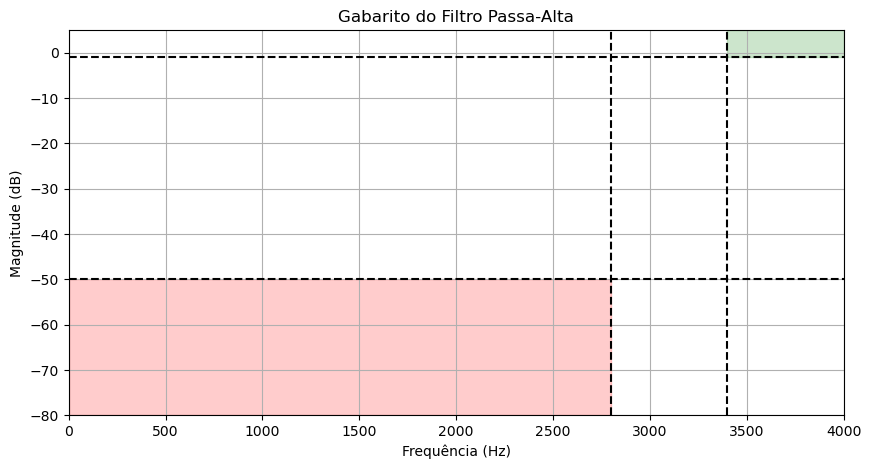

In [5]:
plt.figure(figsize=(10,5))

# banda rejeição
plt.fill_between(
    [0,2800],
    [-80,-80],
    [-50,-50],
    color='red',
    alpha=0.2
)

# banda passante
plt.fill_between(
    [3400,4000],
    [-1,-1],
    [5,5],
    color='green',
    alpha=0.2
)

plt.axvline(
    2800,
    color='black',
    linestyle='--'
)

plt.axvline(
    3400,
    color='black',
    linestyle='--'
)

plt.axhline(
    -50,
    color='black',
    linestyle='--'
)

plt.axhline(
    -1,
    color='black',
    linestyle='--'
)

plt.title('Gabarito do Filtro Passa-Alta')

plt.xlabel('Frequência (Hz)')

plt.ylabel('Magnitude (dB)')

plt.xlim(0,4000)

plt.ylim(-80,5)

plt.grid()

plt.show()

Número de taps: 41
Ordem do filtro: 40
Beta: 4.533514120981248
Número de multiplicações por amostra: 41

Coeficientes do numerador:
[ 0.00088484 -0.00111006  0.00034482  0.00164384 -0.00410549  0.00531412
 -0.003402   -0.00223921  0.00979769 -0.01508498  0.01327028 -0.00181836
 -0.01680792  0.03442006 -0.03938912  0.02148774  0.02270938 -0.08655988
  0.15423496 -0.20590252  0.22522665 -0.20590252  0.15423496 -0.08655988
  0.02270938  0.02148774 -0.03938912  0.03442006 -0.01680792 -0.00181836
  0.01327028 -0.01508498  0.00979769 -0.00223921 -0.003402    0.00531412
 -0.00410549  0.00164384  0.00034482 -0.00111006  0.00088484]

Coeficientes do denominador:
[1]

Atenuação obtida: 52.0644277852034 dB
Ripple obtido: 0.04567964718205786 dB

O filtro FIR projetado pela janela
de Kaiser apresentou ondulação
significativamente inferior ao
limite especificado de 1 dB,
resultando em uma banda passante
praticamente plana.

A resposta de fase apresentou
comportamento aproximadamente
linear, caracter

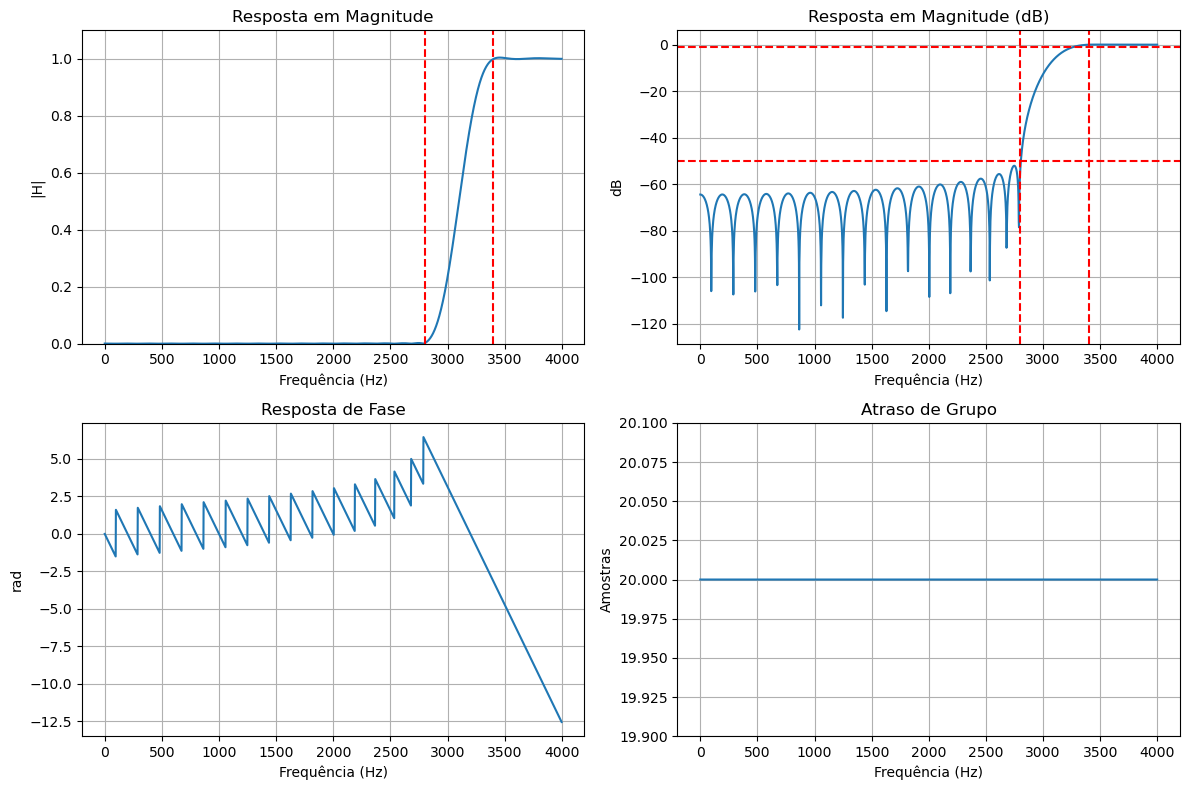

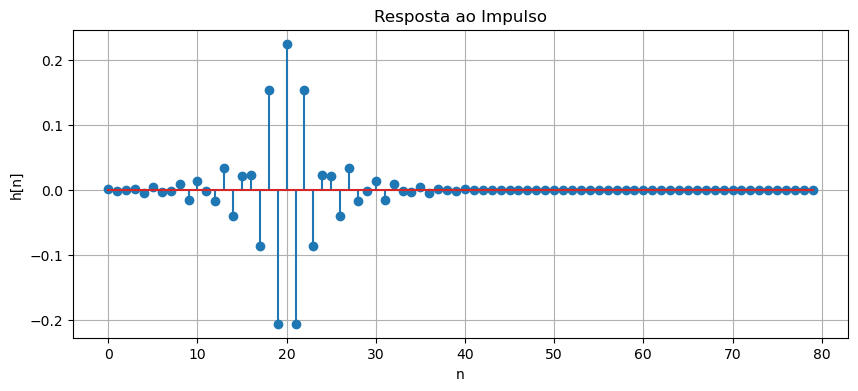


A resposta ao impulso
apresentou simetria em
torno de n = 20 amostras,
consistente com o atraso
de grupo constante esperado
para filtros FIR linear-phase.


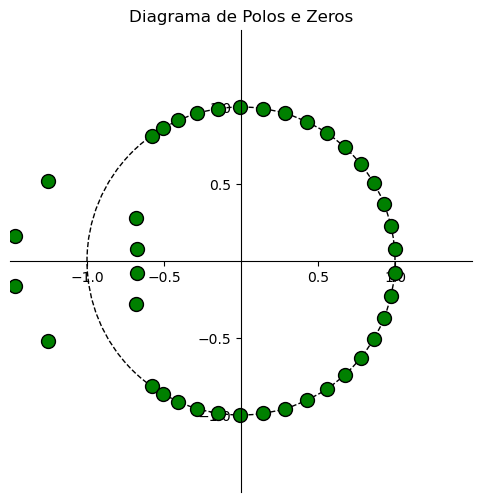


O filtro FIR apresentou
apenas polos triviais
na origem do plano-z.

Os zeros distribuíram-se
próximos ao círculo
unitário, característica
típica de filtros FIR
seletivos.


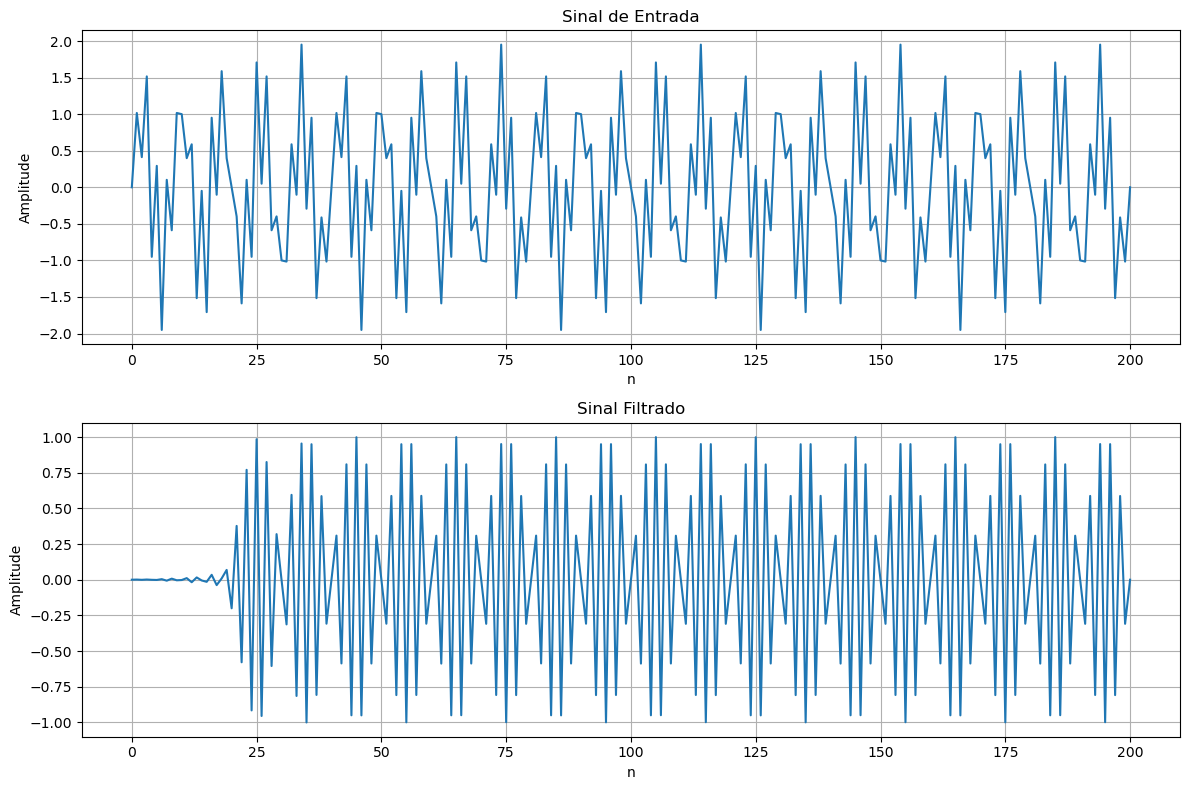

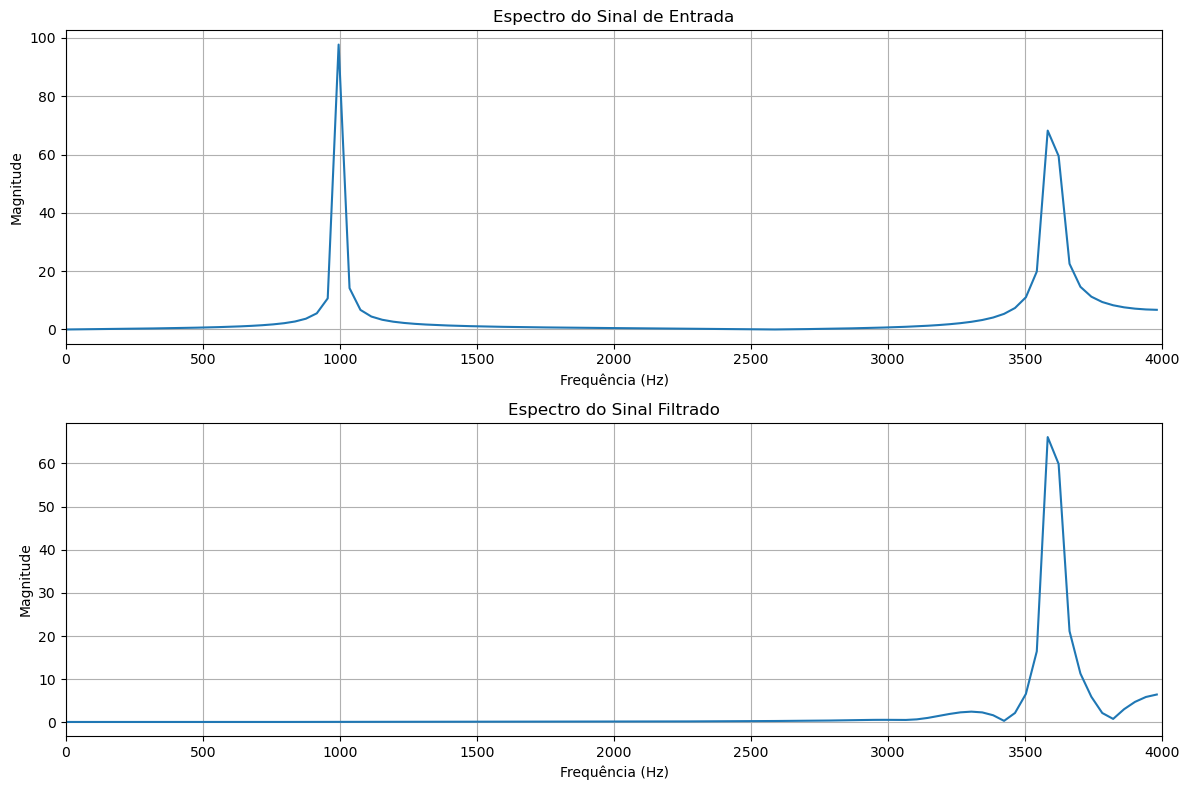


O teste com senoides
demonstrou que o filtro
atenuou fortemente a
componente de 1000 Hz,
preservando a componente
de 3600 Hz localizada
na banda passante.


In [6]:
# =========================================================
# FIR Kaiser
# =========================================================

# =========================================================
# Especificações
# =========================================================

fs = 8000

fp = 3400
fsb = 2800

Rp = 1      # dB
As = 50     # dB

Wp = fp/(fs/2)
Ws = fsb/(fs/2)

# =========================================================
# Projeto do filtro
# =========================================================

N_kaiser, beta = signal.kaiserord(As, Wp-Ws)

# Para filtros passa-alta FIR, o número de taps
# deve ser ímpar

if N_kaiser % 2 == 0:
    N_kaiser += 1

print("Número de taps:", N_kaiser)
print("Ordem do filtro:", N_kaiser - 1)
print("Beta:", beta)

# Em FIR por janela, o cutoff representa
# aproximadamente o centro da banda de transição

fc = (fp + fsb)/2

b_kaiser = signal.firwin(
    N_kaiser,
    cutoff=fc,
    fs=fs,
    pass_zero=False,
    window=('kaiser', beta)
)

a_kaiser = [1]

# =========================================================
# Número de multiplicações
# =========================================================

print("Número de multiplicações por amostra:",
      N_kaiser)

# =========================================================
# Lista de coeficientes
# =========================================================
print("\nCoeficientes do numerador:")

print(b_kaiser)

print("\nCoeficientes do denominador:")

print(a_kaiser)

# =========================================================
# Resposta em frequência
# =========================================================

db, mag, pha, grd, w = freqz_m(
    b_kaiser,
    a_kaiser
)

f = w*fs/(2*np.pi)

# =========================================================
# Verificação das especificações
# =========================================================

idx_stop = np.where(f <= 2800)

As_real = -np.max(db[idx_stop])

idx_pass = np.where(
    (f >= 3400) &
    (f <= 3900)
)

Rp_real = (
    np.max(db[idx_pass])
    -
    np.min(db[idx_pass])
)

print("\nAtenuação obtida:",
      As_real,
      "dB")

print("Ripple obtido:",
      Rp_real,
      "dB")

print("\nO filtro FIR projetado pela janela")
print("de Kaiser apresentou ondulação")
print("significativamente inferior ao")
print("limite especificado de 1 dB,")
print("resultando em uma banda passante")
print("praticamente plana.")

# =========================================================
# Resposta de fase
# =========================================================

pha_unwrap = np.unwrap(pha)

print("\nA resposta de fase apresentou")
print("comportamento aproximadamente")
print("linear, característica típica")
print("de filtros FIR com coeficientes")
print("simétricos.")

# =========================================================
# Atraso de grupo
# =========================================================

# Para FIR linear-phase:
#
# atraso = (N-1)/2
#
# Como N = número de taps:
#
# atraso = (41-1)/2 = 20 amostras

idx_gd = np.where(
    (f >= 3400) &
    (f <= 3900)
)

print("\nAtraso médio de grupo:",
      np.mean(grd[idx_gd]),
      "amostras")

print("\nO atraso de grupo apresentou")
print("comportamento aproximadamente")
print("constante na banda passante,")
print("característica típica de")
print("filtros FIR linear-phase.")

print("\nO filtro apresentou fase")
print("aproximadamente linear e")
print("atraso de grupo constante,")
print("reduzindo distorções de")
print("fase no sinal filtrado.")

# =========================================================
# Gráficos principais
# =========================================================

fig, axs = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12,8)
)

# ---------------------------------------------------------
# Magnitude linear
# ---------------------------------------------------------

axs[0,0].plot(f, mag)

axs[0,0].axvline(
    2800,
    color='r',
    linestyle='--'
)

axs[0,0].axvline(
    3400,
    color='r',
    linestyle='--'
)

axs[0,0].set_ylim(0,1.1)

axs[0,0].set_title(
    'Resposta em Magnitude'
)

axs[0,0].set_xlabel(
    'Frequência (Hz)'
)

axs[0,0].set_ylabel('|H|')

axs[0,0].grid()

# ---------------------------------------------------------
# Magnitude em dB
# ---------------------------------------------------------

axs[0,1].plot(f, db)

axs[0,1].axhline(
    -Rp,
    color='r',
    linestyle='--'
)

axs[0,1].axhline(
    -As,
    color='r',
    linestyle='--'
)

axs[0,1].axvline(
    2800,
    color='r',
    linestyle='--'
)

axs[0,1].axvline(
    3400,
    color='r',
    linestyle='--'
)

axs[0,1].set_title(
    'Resposta em Magnitude (dB)'
)

axs[0,1].set_xlabel(
    'Frequência (Hz)'
)

axs[0,1].set_ylabel('dB')

axs[0,1].grid()

# ---------------------------------------------------------
# Fase
# ---------------------------------------------------------

axs[1,0].plot(f, pha_unwrap)

axs[1,0].set_title(
    'Resposta de Fase'
)

axs[1,0].set_xlabel(
    'Frequência (Hz)'
)

axs[1,0].set_ylabel('rad')

axs[1,0].grid()

# ---------------------------------------------------------
# Atraso de grupo
# ---------------------------------------------------------

axs[1,1].plot(f, grd)

axs[1,1].ticklabel_format(
    style='plain',
    axis='y',
    useOffset=False
)

axs[1,1].set_ylim(19.9,20.1)

axs[1,1].set_title(
    'Atraso de Grupo'
)

axs[1,1].set_xlabel(
    'Frequência (Hz)'
)

axs[1,1].set_ylabel(
    'Amostras'
)

axs[1,1].grid()

fig.tight_layout()

plt.show()

# =========================================================
# Resposta ao impulso
# =========================================================

delta, n = impseq(0,0,79)

h = signal.lfilter(
    b_kaiser,
    a_kaiser,
    delta
)

plt.figure(figsize=(10,4))

plt.stem(n, h)

plt.title(
    'Resposta ao Impulso'
)

plt.xlabel('n')

plt.ylabel('h[n]')

plt.grid()

plt.show()

print("\nA resposta ao impulso")
print("apresentou simetria em")
print("torno de n = 20 amostras,")
print("consistente com o atraso")
print("de grupo constante esperado")
print("para filtros FIR linear-phase.")

# =========================================================
# Polos e zeros
# =========================================================

plt.figure(figsize=(6,6))

zplane(
    b_kaiser,
    a_kaiser
)

plt.title(
    'Diagrama de Polos e Zeros'
)

plt.show()

print("\nO filtro FIR apresentou")
print("apenas polos triviais")
print("na origem do plano-z.")

print("\nOs zeros distribuíram-se")
print("próximos ao círculo")
print("unitário, característica")
print("típica de filtros FIR")
print("seletivos.")

# =========================================================
# Teste do filtro com senoides
# =========================================================

# ---------------------------------------------------------
# eixo temporal
# ---------------------------------------------------------

n = discrete_time_range(0,200)

# ---------------------------------------------------------
# frequências
# ---------------------------------------------------------

f1 = 1000
f2 = 3600

w1 = analog_to_digital_frequency(
    f1,
    fs
)

w2 = analog_to_digital_frequency(
    f2,
    fs
)

# ---------------------------------------------------------
# sinais
# ---------------------------------------------------------

x1 = sine(1, w1, n)

x2 = sine(1, w2, n)

# Sinal composto

x = x1 + x2

# ---------------------------------------------------------
# filtragem
# ---------------------------------------------------------

y = apply_filter(
    b_kaiser,
    a_kaiser,
    x
)

# =========================================================
# Sinais no tempo
# =========================================================

plt.figure(figsize=(12,8))

# ---------------------------------------------------------
# entrada
# ---------------------------------------------------------

plt.subplot(2,1,1)

plt.plot(n, x)

plt.title(
    'Sinal de Entrada'
)

plt.xlabel('n')

plt.ylabel('Amplitude')

plt.grid()

# ---------------------------------------------------------
# saída
# ---------------------------------------------------------

plt.subplot(2,1,2)

plt.plot(n, y)

plt.title(
    'Sinal Filtrado'
)

plt.xlabel('n')

plt.ylabel('Amplitude')

plt.grid()

plt.tight_layout()

plt.show()

# =========================================================
# Espectros
# =========================================================

f_in, X = fft_spectrum(x, fs)

f_out, Y = fft_spectrum(y, fs)

plt.figure(figsize=(12,8))

# ---------------------------------------------------------
# espectro entrada
# ---------------------------------------------------------

plt.subplot(2,1,1)

plt.plot(f_in, X)

plt.xlim(0,4000)

plt.title(
    'Espectro do Sinal de Entrada'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Magnitude'
)

plt.grid()

# ---------------------------------------------------------
# espectro saída
# ---------------------------------------------------------

plt.subplot(2,1,2)

plt.plot(f_out, Y)

plt.xlim(0,4000)

plt.title(
    'Espectro do Sinal Filtrado'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Magnitude'
)

plt.grid()

plt.tight_layout()

plt.show()

print("\nO teste com senoides")
print("demonstrou que o filtro")
print("atenuou fortemente a")
print("componente de 1000 Hz,")
print("preservando a componente")
print("de 3600 Hz localizada")
print("na banda passante.")

# =========================================================
# Salvando métricas
# =========================================================

Rp_real_kaiser = Rp_real

As_real_kaiser = As_real

gd_kaiser = np.mean(
    grd[idx_gd]
)

Número de taps: 41
Ordem do filtro: 40
Número de multiplicações por amostra: 41

Coeficientes do numerador:
[ 0.00127168 -0.00108994  0.00028324  0.00127161 -0.00317198  0.0042047
 -0.00277962 -0.00189061  0.00852736 -0.01348547  0.01213935 -0.00169606
 -0.01593396  0.03307017 -0.03825917  0.02105413  0.02240289 -0.08582662
  0.1534677  -0.20530256  0.22472371 -0.20530256  0.1534677  -0.08582662
  0.02240289  0.02105413 -0.03825917  0.03307017 -0.01593396 -0.00169606
  0.01213935 -0.01348547  0.00852736 -0.00189061 -0.00277962  0.0042047
 -0.00317198  0.00127161  0.00028324 -0.00108994  0.00127168]

Coeficientes do denominador:
[1]

Atenuação obtida: 39.872711191674455 dB
Ripple obtido: 0.11751931564705062 dB

O filtro FIR projetado pela
janela de Hamming apresentou
banda passante praticamente
plana e fase aproximadamente
linear.

Entretanto, para a ordem
utilizada, a atenuação da
banda de rejeição não
atingiu os 50 dB
especificados.

A resposta obtida evidencia
a limitação da janela d

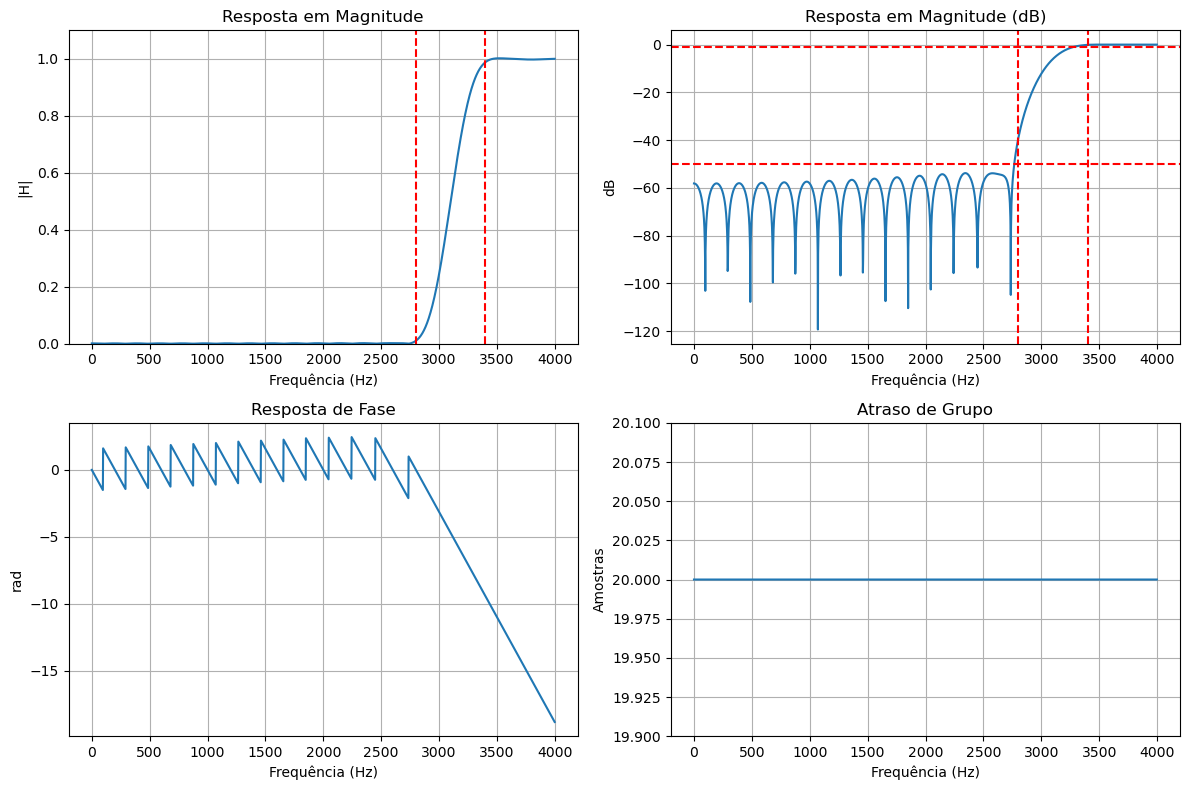

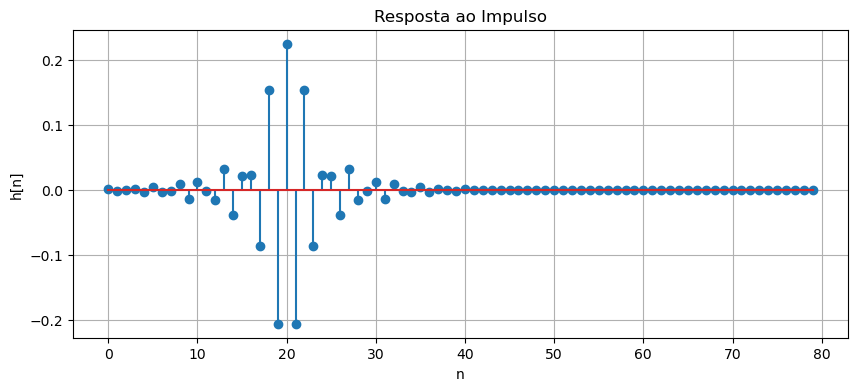


A resposta ao impulso
apresentou simetria em
torno de n = 20 amostras,
consistente com o atraso
de grupo constante esperado
para filtros FIR linear-phase.


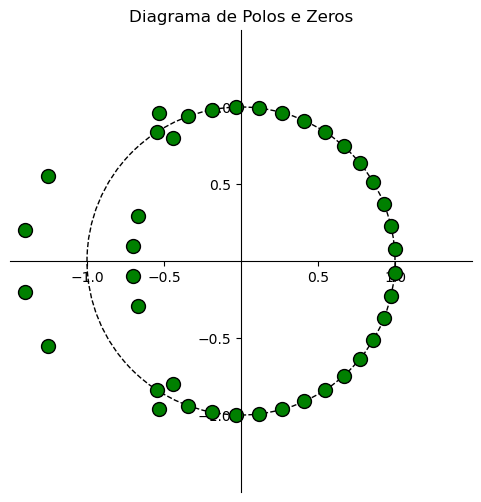


O filtro FIR apresentou
apenas polos triviais
na origem do plano-z.

Os zeros distribuíram-se
próximos ao círculo
unitário, característica
típica de filtros FIR
seletivos e linear-phase..


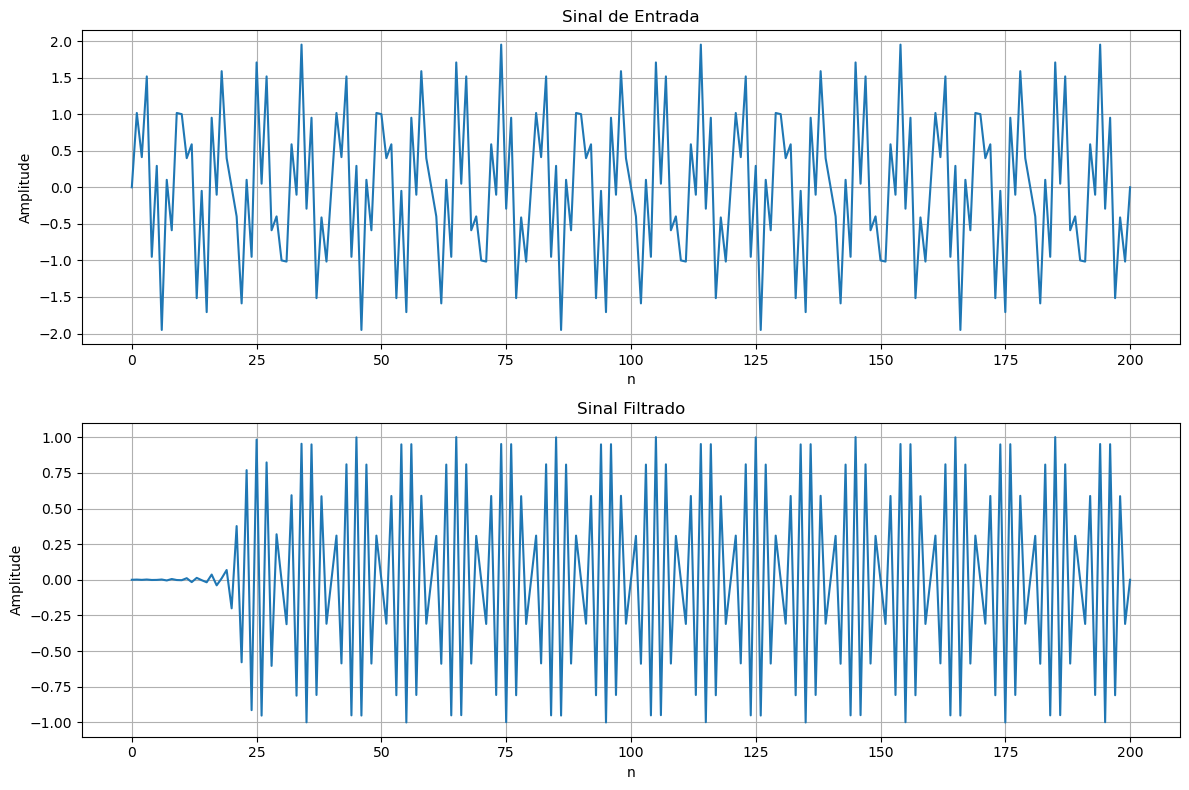

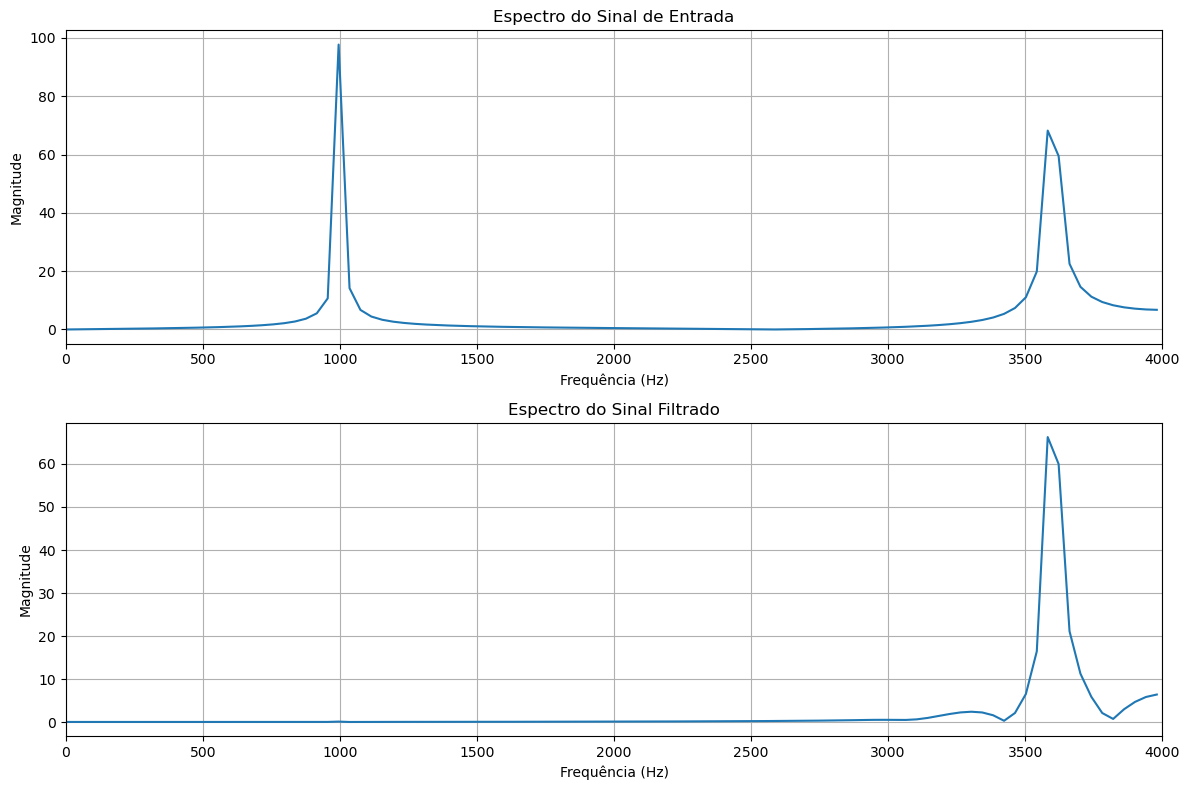


O teste com senoides
demonstrou que o filtro
atenuou fortemente a
componente de 1000 Hz,
preservando a componente
de 3600 Hz localizada
na banda passante.

Comparando-se com o filtro
projetado pela janela de
Kaiser, observou-se que a
janela de Hamming apresentou
comportamento temporal
semelhante, porém menor
capacidade de rejeição na
banda de parada.

Isso ocorreu porque a
janela de Kaiser permite
controle mais flexível das
características espectrais
através do parâmetro beta.


In [7]:
# =========================================================
# FIR Hamming
# =========================================================

# =========================================================
# Especificações
# =========================================================

fs = 8000

fp = 3400
fsb = 2800

Rp = 1      # dB
As = 50     # dB

Wp = fp/(fs/2)
Ws = fsb/(fs/2)

# =========================================================
# Projeto do filtro
# =========================================================

# A janela de Hamming apresenta
# boa rejeição espectral e fase
# linear, sendo amplamente utilizada
# em projetos FIR por janelamento.
#
# A ordem foi escolhida para permitir
# comparação direta com o filtro
# projetado pela janela de Kaiser.

N_hamming = 41

# Para filtros passa-alta FIR,
# o número de taps deve ser ímpar

if N_hamming % 2 == 0:
    N_hamming += 1

print("Número de taps:", N_hamming)

print("Ordem do filtro:",
      N_hamming - 1)

# Em FIR por janela, o cutoff representa
# aproximadamente o centro da banda
# de transição

fc = (fp + fsb)/2

b_hamming = signal.firwin(
    N_hamming,
    cutoff=fc,
    fs=fs,
    pass_zero=False,
    window='hamming'
)

a_hamming = [1]

# =========================================================
# Número de multiplicações
# =========================================================

print("Número de multiplicações por amostra:",
      N_hamming)

# =========================================================
# Lista de coeficientes
# =========================================================
print("\nCoeficientes do numerador:")

print(b_hamming)

print("\nCoeficientes do denominador:")

print(a_hamming)

# =========================================================
# Resposta em frequência
# =========================================================

db, mag, pha, grd, w = freqz_m(
    b_hamming,
    a_hamming
)

f = w*fs/(2*np.pi)

# =========================================================
# Verificação das especificações
# =========================================================

idx_stop = np.where(f <= 2800)

As_real = -np.max(db[idx_stop])

idx_pass = np.where(
    (f >= 3400) &
    (f <= 3900)
)

Rp_real = (
    np.max(db[idx_pass])
    -
    np.min(db[idx_pass])
)

print("\nAtenuação obtida:",
      As_real,
      "dB")

print("Ripple obtido:",
      Rp_real,
      "dB")

print("\nO filtro FIR projetado pela")
print("janela de Hamming apresentou")
print("banda passante praticamente")
print("plana e fase aproximadamente")
print("linear.")

print("\nEntretanto, para a ordem")
print("utilizada, a atenuação da")
print("banda de rejeição não")
print("atingiu os 50 dB")
print("especificados.")

print("\nA resposta obtida evidencia")
print("a limitação da janela de")
print("Hamming em fornecer elevada")
print("rejeição espectral para")
print("larguras de transição")
print("reduzidas.")

# =========================================================
# Resposta de fase
# =========================================================

pha_unwrap = np.unwrap(pha)

print("\nA resposta de fase apresentou")
print("comportamento aproximadamente")
print("linear, característica típica")
print("de filtros FIR com coeficientes")
print("simétricos.")

# =========================================================
# Atraso de grupo
# =========================================================

idx_gd = np.where(
    (f >= 3400) &
    (f <= 3900)
)

print("\nAtraso médio de grupo:",
      np.mean(grd[idx_gd]),
      "amostras")

print("\nO atraso de grupo apresentou")
print("comportamento aproximadamente")
print("constante na banda passante,")
print("característica típica de")
print("filtros FIR linear-phase.")

print("\nO filtro apresentou fase")
print("aproximadamente linear e")
print("atraso de grupo constante,")
print("reduzindo distorções de")
print("fase no sinal filtrado.")

# =========================================================
# Gráficos principais
# =========================================================

fig, axs = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12,8)
)

# ---------------------------------------------------------
# Magnitude linear
# ---------------------------------------------------------

axs[0,0].plot(f, mag)

axs[0,0].axvline(
    2800,
    color='r',
    linestyle='--'
)

axs[0,0].axvline(
    3400,
    color='r',
    linestyle='--'
)

axs[0,0].set_ylim(0,1.1)

axs[0,0].set_title(
    'Resposta em Magnitude'
)

axs[0,0].set_xlabel(
    'Frequência (Hz)'
)

axs[0,0].set_ylabel('|H|')

axs[0,0].grid()

# ---------------------------------------------------------
# Magnitude em dB
# ---------------------------------------------------------

axs[0,1].plot(f, db)

axs[0,1].axhline(
    -Rp,
    color='r',
    linestyle='--'
)

axs[0,1].axhline(
    -As,
    color='r',
    linestyle='--'
)

axs[0,1].axvline(
    2800,
    color='r',
    linestyle='--'
)

axs[0,1].axvline(
    3400,
    color='r',
    linestyle='--'
)

axs[0,1].set_title(
    'Resposta em Magnitude (dB)'
)

axs[0,1].set_xlabel(
    'Frequência (Hz)'
)

axs[0,1].set_ylabel('dB')

axs[0,1].grid()

# ---------------------------------------------------------
# Fase
# ---------------------------------------------------------

axs[1,0].plot(f, pha_unwrap)

axs[1,0].set_title(
    'Resposta de Fase'
)

axs[1,0].set_xlabel(
    'Frequência (Hz)'
)

axs[1,0].set_ylabel('rad')

axs[1,0].grid()

# ---------------------------------------------------------
# Atraso de grupo
# ---------------------------------------------------------

axs[1,1].plot(f, grd)

axs[1,1].ticklabel_format(
    style='plain',
    axis='y',
    useOffset=False
)

axs[1,1].set_ylim(19.9,20.1)

axs[1,1].set_title(
    'Atraso de Grupo'
)

axs[1,1].set_xlabel(
    'Frequência (Hz)'
)

axs[1,1].set_ylabel(
    'Amostras'
)

axs[1,1].grid()

fig.tight_layout()

plt.show()

# =========================================================
# Resposta ao impulso
# =========================================================

delta, n = impseq(0,0,79)

h = signal.lfilter(
    b_hamming,
    a_hamming,
    delta
)

plt.figure(figsize=(10,4))

plt.stem(n, h)

plt.title(
    'Resposta ao Impulso'
)

plt.xlabel('n')

plt.ylabel('h[n]')

plt.grid()

plt.show()

print("\nA resposta ao impulso")
print("apresentou simetria em")
print("torno de n = 20 amostras,")
print("consistente com o atraso")
print("de grupo constante esperado")
print("para filtros FIR linear-phase.")

# =========================================================
# Polos e zeros
# =========================================================

plt.figure(figsize=(6,6))

zplane(
    b_hamming,
    a_hamming
)

plt.title(
    'Diagrama de Polos e Zeros'
)

plt.show()

print("\nO filtro FIR apresentou")
print("apenas polos triviais")
print("na origem do plano-z.")

print("\nOs zeros distribuíram-se")
print("próximos ao círculo")
print("unitário, característica")
print("típica de filtros FIR")
print("seletivos e linear-phase..")

# =========================================================
# Teste do filtro com senoides
# =========================================================

# ---------------------------------------------------------
# eixo temporal
# ---------------------------------------------------------

n = discrete_time_range(0,200)

# ---------------------------------------------------------
# frequências
# ---------------------------------------------------------

f1 = 1000
f2 = 3600

w1 = analog_to_digital_frequency(
    f1,
    fs
)

w2 = analog_to_digital_frequency(
    f2,
    fs
)

# ---------------------------------------------------------
# sinais
# ---------------------------------------------------------

x1 = sine(1, w1, n)

x2 = sine(1, w2, n)

# sinal composto

x = x1 + x2

# ---------------------------------------------------------
# filtragem
# ---------------------------------------------------------

y = apply_filter(
    b_hamming,
    a_hamming,
    x
)

# =========================================================
# Sinais no tempo
# =========================================================

plt.figure(figsize=(12,8))

# ---------------------------------------------------------
# entrada
# ---------------------------------------------------------

plt.subplot(2,1,1)

plt.plot(n, x)

plt.title(
    'Sinal de Entrada'
)

plt.xlabel('n')

plt.ylabel('Amplitude')

plt.grid()

# ---------------------------------------------------------
# saída
# ---------------------------------------------------------

plt.subplot(2,1,2)

plt.plot(n, y)

plt.title(
    'Sinal Filtrado'
)

plt.xlabel('n')

plt.ylabel('Amplitude')

plt.grid()

plt.tight_layout()

plt.show()

# =========================================================
# Espectros
# =========================================================

f_in, X = fft_spectrum(x, fs)

f_out, Y = fft_spectrum(y, fs)

plt.figure(figsize=(12,8))

# ---------------------------------------------------------
# espectro entrada
# ---------------------------------------------------------

plt.subplot(2,1,1)

plt.plot(f_in, X)

plt.xlim(0,4000)

plt.title(
    'Espectro do Sinal de Entrada'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Magnitude'
)

plt.grid()

# ---------------------------------------------------------
# espectro saída
# ---------------------------------------------------------

plt.subplot(2,1,2)

plt.plot(f_out, Y)

plt.xlim(0,4000)

plt.title(
    'Espectro do Sinal Filtrado'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Magnitude'
)

plt.grid()

plt.tight_layout()

plt.show()

print("\nO teste com senoides")
print("demonstrou que o filtro")
print("atenuou fortemente a")
print("componente de 1000 Hz,")
print("preservando a componente")
print("de 3600 Hz localizada")
print("na banda passante.")

print("\nComparando-se com o filtro")
print("projetado pela janela de")
print("Kaiser, observou-se que a")
print("janela de Hamming apresentou")
print("comportamento temporal")
print("semelhante, porém menor")
print("capacidade de rejeição na")
print("banda de parada.")

print("\nIsso ocorreu porque a")
print("janela de Kaiser permite")
print("controle mais flexível das")
print("características espectrais")
print("através do parâmetro beta.")

# =========================================================
# Salvando métricas
# =========================================================

Rp_real_hamming = Rp_real

As_real_hamming = As_real

gd_hamming = np.mean(
    grd[idx_gd]
)

Wp = 0.85
Ws = 0.7
Ordem do filtro: 6
Frequência crítica: 0.741353623334665
Número de seções biquadráticas: 3
Número de multiplicações por amostra: 27

Coeficientes do numerador:
[0.00662986 0.00875257 0.01402155 0.00986436 0.01402155 0.00875257
 0.00662986]

Coeficientes do denominador:
[1.         3.87411357 6.52678356 6.04146574 3.22305443 0.93550217
 0.1151768 ]

Atenuação obtida: 50.000000000000036 dB
Ripple obtido: 0.9913035661273846 dB

O filtro IIR Chebyshev II
apresentou fase não linear,
característica típica de
filtros recursivos.

Atraso médio de grupo: 8.06967560066428 amostras

O atraso de grupo não
permaneceu constante ao
longo da banda passante,
indicando distorção de
fase no sinal filtrado.


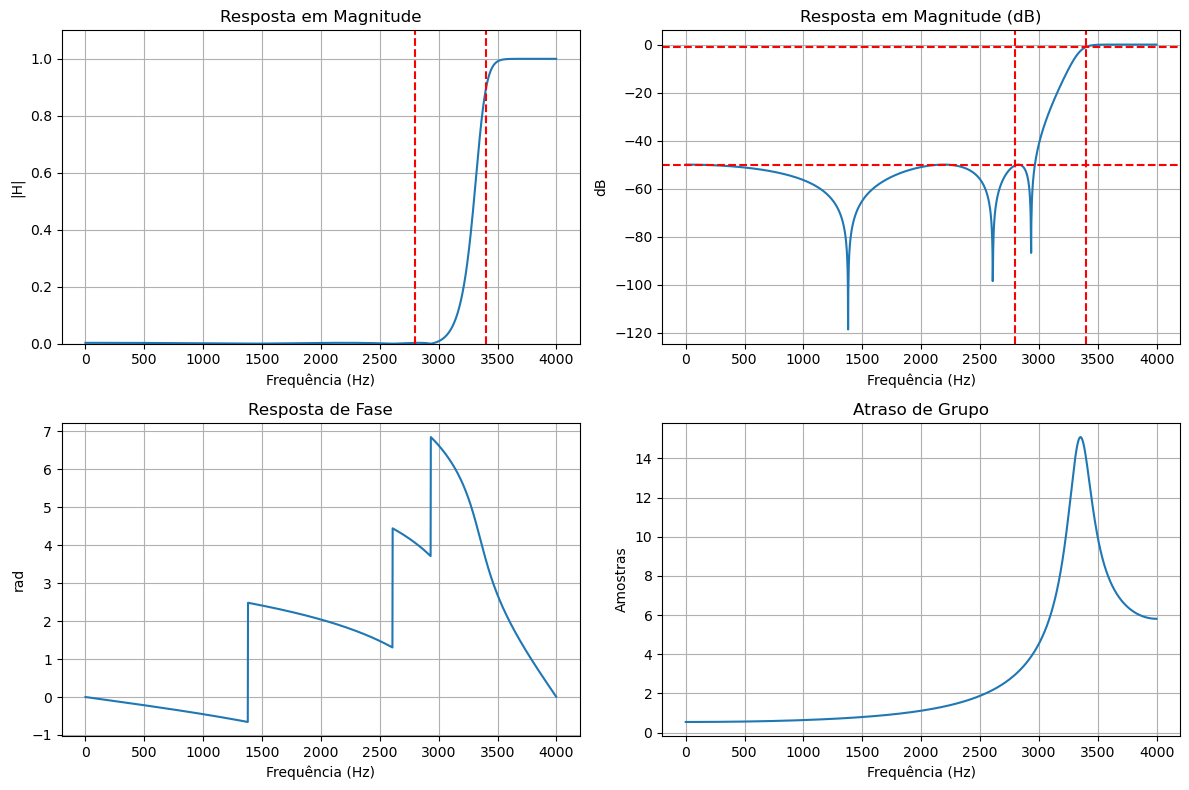

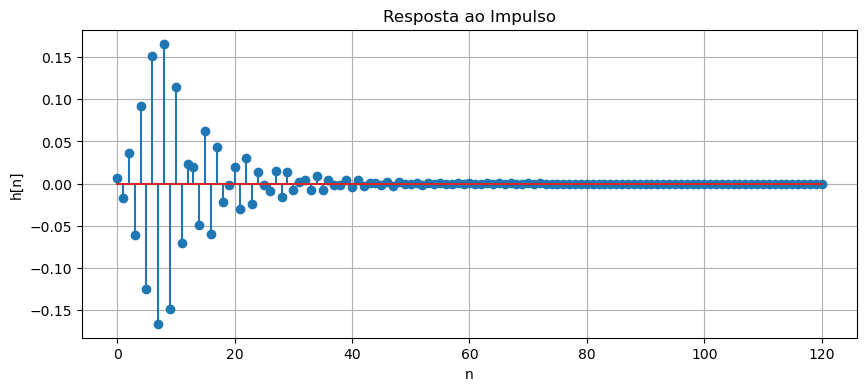


A resposta ao impulso
apresentou comportamento
oscilatório com decaimento
ao longo do tempo,
característica típica
de filtros IIR recursivos.

Diferentemente dos filtros
FIR analisados anteriormente,
a resposta ao impulso do
filtro IIR possui duração
teoricamente infinita.


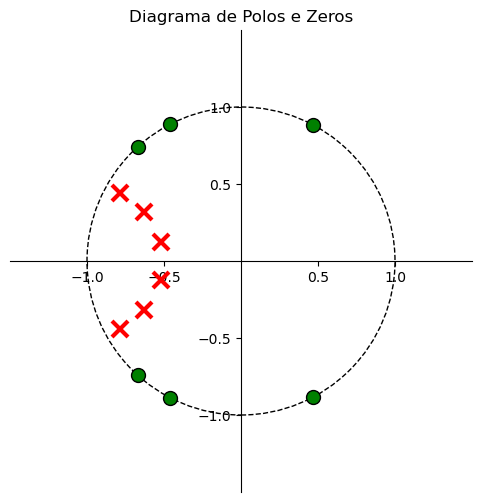


Os polos do filtro
permaneceram internos
ao círculo unitário,
garantindo estabilidade.

Os zeros distribuíram-se
próximos ao círculo
unitário na banda de
rejeição, característica
típica de filtros
Chebyshev Tipo II.


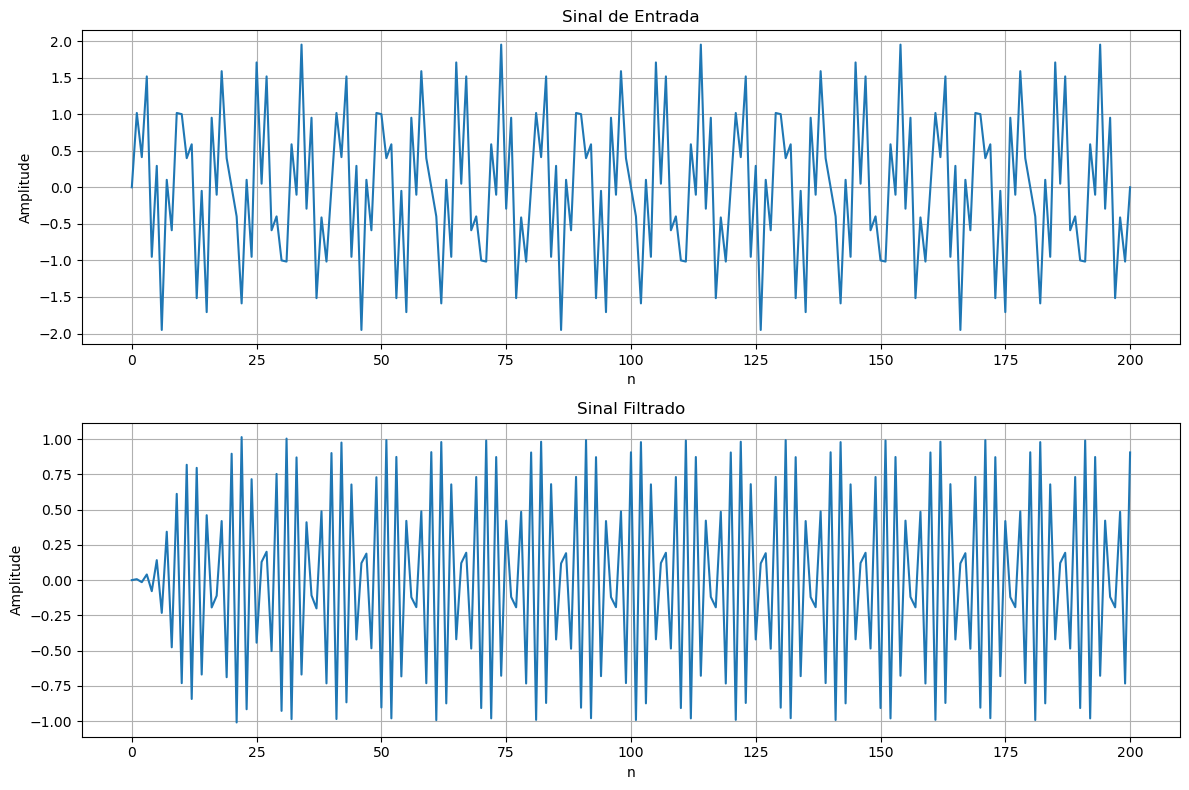

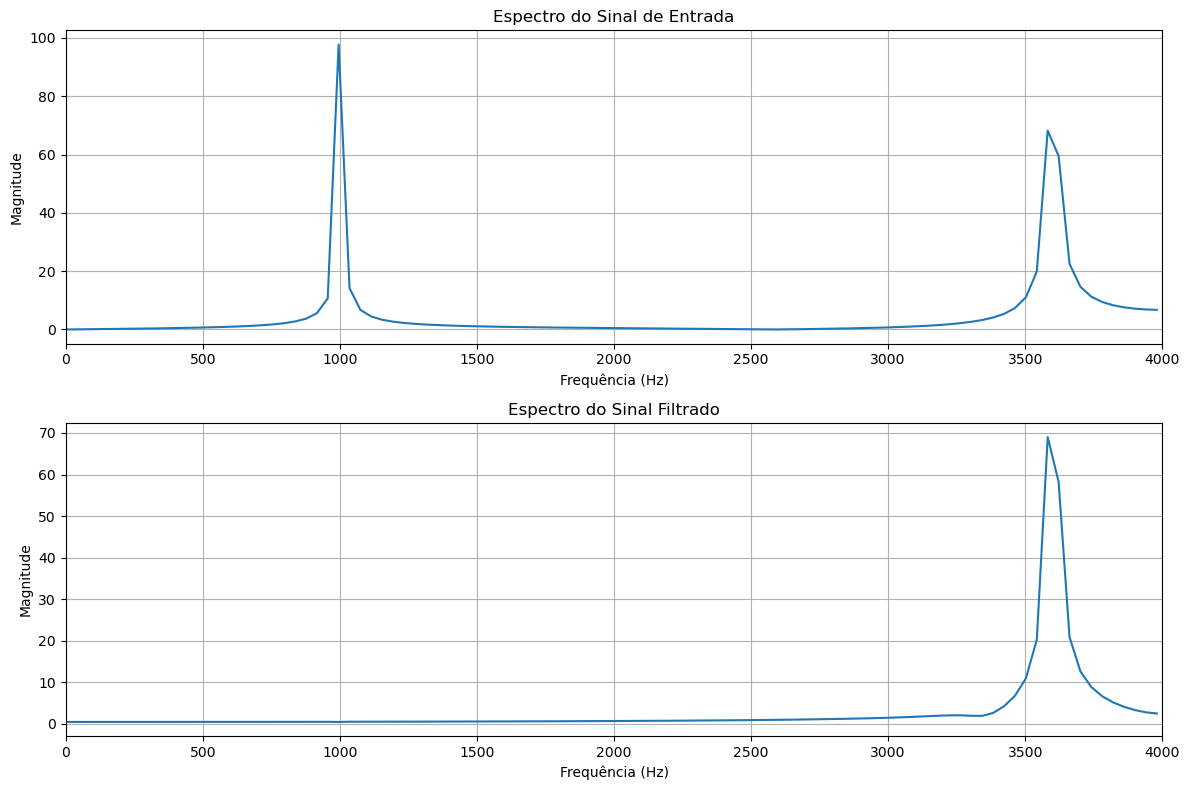


O teste com senoides
demonstrou que o filtro
atenuou fortemente a
componente de 1000 Hz,
preservando a componente
de 3600 Hz localizada
na banda passante.

Comparando-se com os
filtros FIR analisados
anteriormente, o filtro
IIR apresentou ordem
consideravelmente menor,
porém com fase não linear
e atraso de grupo variável.


In [8]:
# =========================================================
# IIR Chebyshev II
# =========================================================

# =========================================================
# Especificações
# =========================================================

fs = 8000

fp = 3400
fsb = 2800

Rp = 1      # dB
As = 50     # dB

# =========================================================
# Frequências digitais normalizadas
# =========================================================

Wp = fp/(fs/2)

Ws = fsb/(fs/2)

print("Wp =", Wp)

print("Ws =", Ws)

# =========================================================
# Projeto do filtro
# =========================================================

N_cheb2, Wn_cheb2 = signal.cheb2ord(
    wp=Wp,
    ws=Ws,
    gpass=Rp,
    gstop=As
)

print("Ordem do filtro:",
      N_cheb2)

print("Frequência crítica:",
      Wn_cheb2)

b_cheb2, a_cheb2 = signal.cheby2(
    N_cheb2,
    As,
    Wn_cheb2,
    btype='high'
)

# =========================================================
# Número de multiplicações
# =========================================================

# Em cascata de segunda ordem:
#
# cada seção biquadrática utiliza:
#
# 5 multiplicações no numerador
# 4 multiplicações no denominador
#
# total:
#
# 9 multiplicações por seção

num_sections = int(np.ceil(N_cheb2/2))

mult_cheb2 = 9*num_sections

print("Número de seções biquadráticas:",
      num_sections)

print("Número de multiplicações por amostra:",
      mult_cheb2)

# =========================================================
# Lista de coeficientes
# =========================================================

print("\nCoeficientes do numerador:")

print(b_cheb2)

print("\nCoeficientes do denominador:")

print(a_cheb2)

# =========================================================
# Resposta em frequência
# =========================================================

db, mag, pha, grd, w = freqz_m(
    b_cheb2,
    a_cheb2
)

f = w*fs/(2*np.pi)

# =========================================================
# Verificação das especificações
# =========================================================

idx_stop = np.where(f <= 2800)

As_real = -np.max(db[idx_stop])

idx_pass = np.where(
    (f >= 3400) &
    (f <= 3900)
)

Rp_real = (
    np.max(db[idx_pass])
    -
    np.min(db[idx_pass])
)

print("\nAtenuação obtida:",
      As_real,
      "dB")

print("Ripple obtido:",
      Rp_real,
      "dB")

# =========================================================
# Resposta de fase
# =========================================================

pha_unwrap = np.unwrap(pha)

print("\nO filtro IIR Chebyshev II")
print("apresentou fase não linear,")
print("característica típica de")
print("filtros recursivos.")

# =========================================================
# Atraso de grupo
# =========================================================

idx_gd = np.where(
    (f >= 3400) &
    (f <= 3900)
)

print("\nAtraso médio de grupo:",
      np.mean(grd[idx_gd]),
      "amostras")

print("\nO atraso de grupo não")
print("permaneceu constante ao")
print("longo da banda passante,")
print("indicando distorção de")
print("fase no sinal filtrado.")

# =========================================================
# Gráficos principais
# =========================================================

fig, axs = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12,8)
)

# ---------------------------------------------------------
# Magnitude linear
# ---------------------------------------------------------

axs[0,0].plot(f, mag)

axs[0,0].axvline(
    2800,
    color='r',
    linestyle='--'
)

axs[0,0].axvline(
    3400,
    color='r',
    linestyle='--'
)

axs[0,0].set_ylim(0,1.1)

axs[0,0].set_title(
    'Resposta em Magnitude'
)

axs[0,0].set_xlabel(
    'Frequência (Hz)'
)

axs[0,0].set_ylabel('|H|')

axs[0,0].grid()

# ---------------------------------------------------------
# Magnitude em dB
# ---------------------------------------------------------

axs[0,1].plot(f, db)

axs[0,1].axhline(
    -Rp,
    color='r',
    linestyle='--'
)

axs[0,1].axhline(
    -As,
    color='r',
    linestyle='--'
)

axs[0,1].axvline(
    2800,
    color='r',
    linestyle='--'
)

axs[0,1].axvline(
    3400,
    color='r',
    linestyle='--'
)

axs[0,1].set_title(
    'Resposta em Magnitude (dB)'
)

axs[0,1].set_xlabel(
    'Frequência (Hz)'
)

axs[0,1].set_ylabel('dB')

axs[0,1].grid()

# ---------------------------------------------------------
# Fase
# ---------------------------------------------------------

axs[1,0].plot(f, pha_unwrap)

axs[1,0].set_title(
    'Resposta de Fase'
)

axs[1,0].set_xlabel(
    'Frequência (Hz)'
)

axs[1,0].set_ylabel('rad')

axs[1,0].grid()

# ---------------------------------------------------------
# Atraso de grupo
# ---------------------------------------------------------

axs[1,1].plot(f, grd)

axs[1,1].ticklabel_format(
    style='plain',
    axis='y',
    useOffset=False
)

axs[1,1].set_title(
    'Atraso de Grupo'
)

axs[1,1].set_xlabel(
    'Frequência (Hz)'
)

axs[1,1].set_ylabel(
    'Amostras'
)

axs[1,1].grid()

fig.tight_layout()

plt.show()

# =========================================================
# Resposta ao impulso
# =========================================================

delta, n = impseq(0,0,120)

h = signal.lfilter(
    b_cheb2,
    a_cheb2,
    delta
)

plt.figure(figsize=(10,4))

plt.stem(n, h)

plt.title(
    'Resposta ao Impulso'
)

plt.xlabel('n')

plt.ylabel('h[n]')

plt.grid()

plt.show()

print("\nA resposta ao impulso")
print("apresentou comportamento")
print("oscilatório com decaimento")
print("ao longo do tempo,")
print("característica típica")
print("de filtros IIR recursivos.")

print("\nDiferentemente dos filtros")
print("FIR analisados anteriormente,")
print("a resposta ao impulso do")
print("filtro IIR possui duração")
print("teoricamente infinita.")

# =========================================================
# Polos e zeros
# =========================================================

plt.figure(figsize=(6,6))

zplane(
    b_cheb2,
    a_cheb2
)

plt.title(
    'Diagrama de Polos e Zeros'
)

plt.show()

print("\nOs polos do filtro")
print("permaneceram internos")
print("ao círculo unitário,")
print("garantindo estabilidade.")

print("\nOs zeros distribuíram-se")
print("próximos ao círculo")
print("unitário na banda de")
print("rejeição, característica")
print("típica de filtros")
print("Chebyshev Tipo II.")

# =========================================================
# Teste do filtro com senoides
# =========================================================

# ---------------------------------------------------------
# eixo temporal
# ---------------------------------------------------------

n = discrete_time_range(0,200)

# ---------------------------------------------------------
# frequências
# ---------------------------------------------------------

f1 = 1000
f2 = 3600

w1 = analog_to_digital_frequency(
    f1,
    fs
)

w2 = analog_to_digital_frequency(
    f2,
    fs
)

# ---------------------------------------------------------
# sinais
# ---------------------------------------------------------

x1 = sine(1, w1, n)

x2 = sine(1, w2, n)

# sinal composto

x = x1 + x2

# ---------------------------------------------------------
# filtragem
# ---------------------------------------------------------

y = apply_filter(
    b_cheb2,
    a_cheb2,
    x
)

# =========================================================
# Sinais no tempo
# =========================================================

plt.figure(figsize=(12,8))

# ---------------------------------------------------------
# entrada
# ---------------------------------------------------------

plt.subplot(2,1,1)

plt.plot(n, x)

plt.title(
    'Sinal de Entrada'
)

plt.xlabel('n')

plt.ylabel('Amplitude')

plt.grid()

# ---------------------------------------------------------
# saída
# ---------------------------------------------------------

plt.subplot(2,1,2)

plt.plot(n, y)

plt.title(
    'Sinal Filtrado'
)

plt.xlabel('n')

plt.ylabel('Amplitude')

plt.grid()

plt.tight_layout()

plt.show()

# =========================================================
# Espectros
# =========================================================

f_in, X = fft_spectrum(x, fs)

f_out, Y = fft_spectrum(y, fs)

plt.figure(figsize=(12,8))

# ---------------------------------------------------------
# espectro entrada
# ---------------------------------------------------------

plt.subplot(2,1,1)

plt.plot(f_in, X)

plt.xlim(0,4000)

plt.title(
    'Espectro do Sinal de Entrada'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Magnitude'
)

plt.grid()

# ---------------------------------------------------------
# espectro saída
# ---------------------------------------------------------

plt.subplot(2,1,2)

plt.plot(f_out, Y)

plt.xlim(0,4000)

plt.title(
    'Espectro do Sinal Filtrado'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Magnitude'
)

plt.grid()

plt.tight_layout()

plt.show()

print("\nO teste com senoides")
print("demonstrou que o filtro")
print("atenuou fortemente a")
print("componente de 1000 Hz,")
print("preservando a componente")
print("de 3600 Hz localizada")
print("na banda passante.")

print("\nComparando-se com os")
print("filtros FIR analisados")
print("anteriormente, o filtro")
print("IIR apresentou ordem")
print("consideravelmente menor,")
print("porém com fase não linear")
print("e atraso de grupo variável.")

# =========================================================
# Salvando métricas
# =========================================================

Rp_real_cheb2 = Rp_real

As_real_cheb2 = As_real

gd_cheb2 = np.mean(
    grd[idx_gd]
)

Wp = 0.85
Ws = 0.7
Ordem do filtro: 4
Frequência crítica: 0.85
Número de seções biquadráticas: 2
Número de multiplicações por amostra: 18

Coeficientes do numerador:
[0.00667643 0.00667106 0.01151003 0.00667106 0.00667643]

Coeficientes do denominador:
[1.         3.34338427 4.40600357 2.69089449 0.64120169]

Atenuação obtida: 49.99997419276753 dB
Ripple obtido: 0.9999405240283726 dB

O filtro IIR elíptico
apresentou fase não
linear, característica
típica de filtros
recursivos altamente
seletivos.

Atraso médio de grupo: 1.9987980247382071 amostras

O atraso de grupo não
permaneceu constante
ao longo da banda
passante, indicando
distorção de fase no
sinal filtrado.


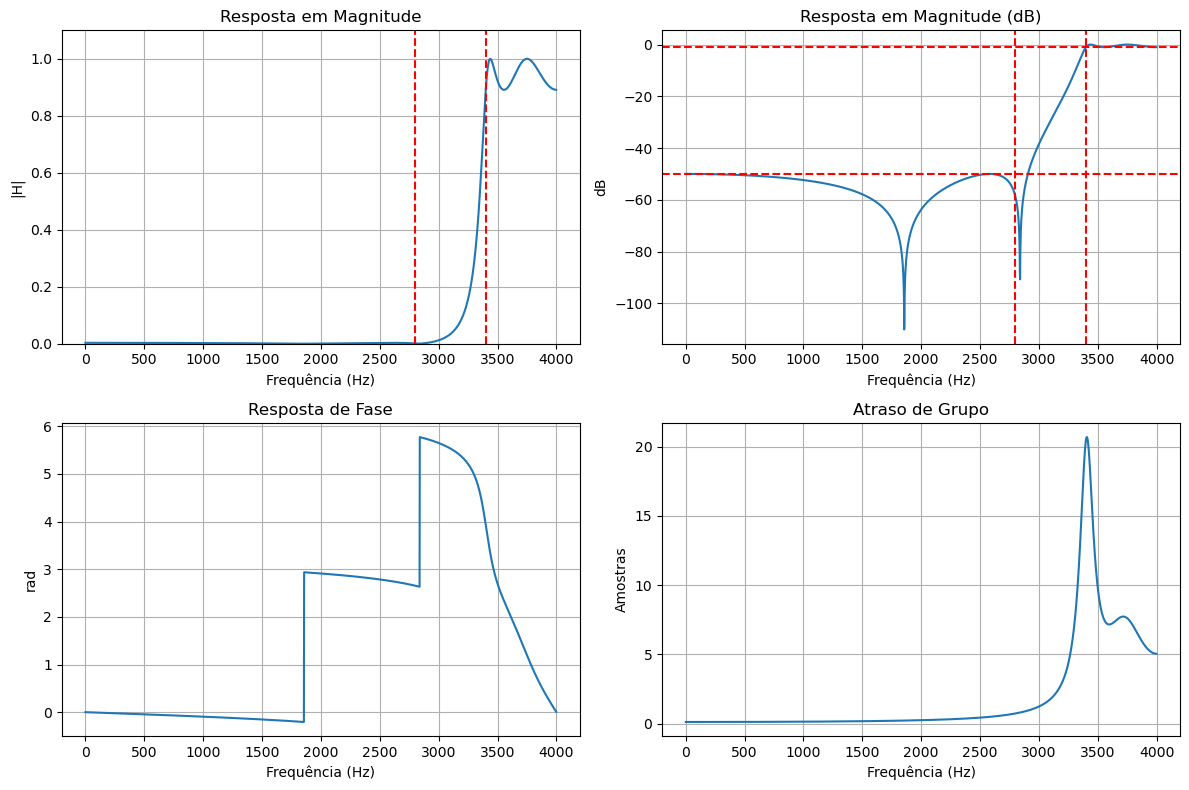


O filtro elíptico apresentou
picos elevados de atraso
de grupo próximos à banda
de transição, característica
associada à elevada
seletividade espectral.


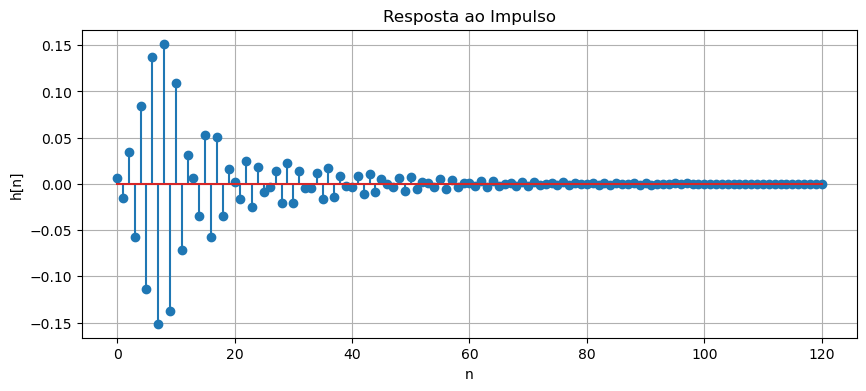


A resposta ao impulso
apresentou comportamento
oscilatório com
decaimento ao longo
do tempo, característica
típica de filtros IIR.

Comparando-se com o
filtro Chebyshev II,
o filtro elíptico
apresentou oscilações
mais pronunciadas na
resposta ao impulso.

Assim como nos demais
filtros IIR, a resposta
ao impulso possui
duração teoricamente
infinita.


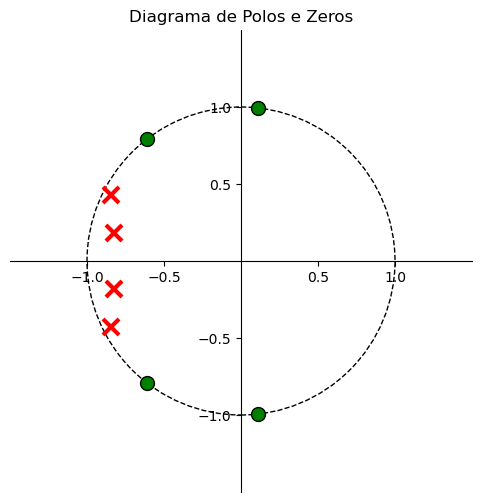


Os polos permaneceram
internos ao círculo
unitário, garantindo
estabilidade do filtro.

Os zeros distribuíram-se
muito próximos ao
círculo unitário,
característica típica
de filtros elípticos
altamente seletivos.

Comparando-se com o
filtro Chebyshev II,
observou-se maior
seletividade espectral
com menor ordem, porém
à custa de maior
não linearidade de
fase.


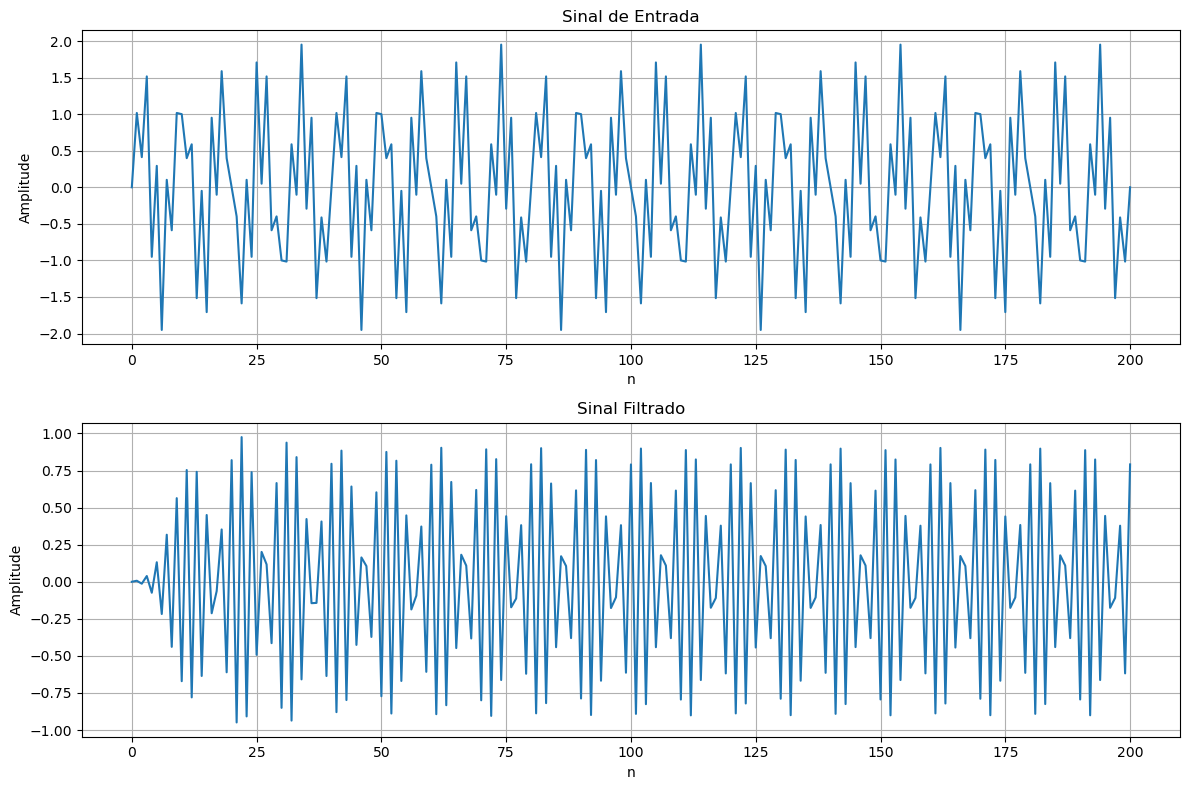

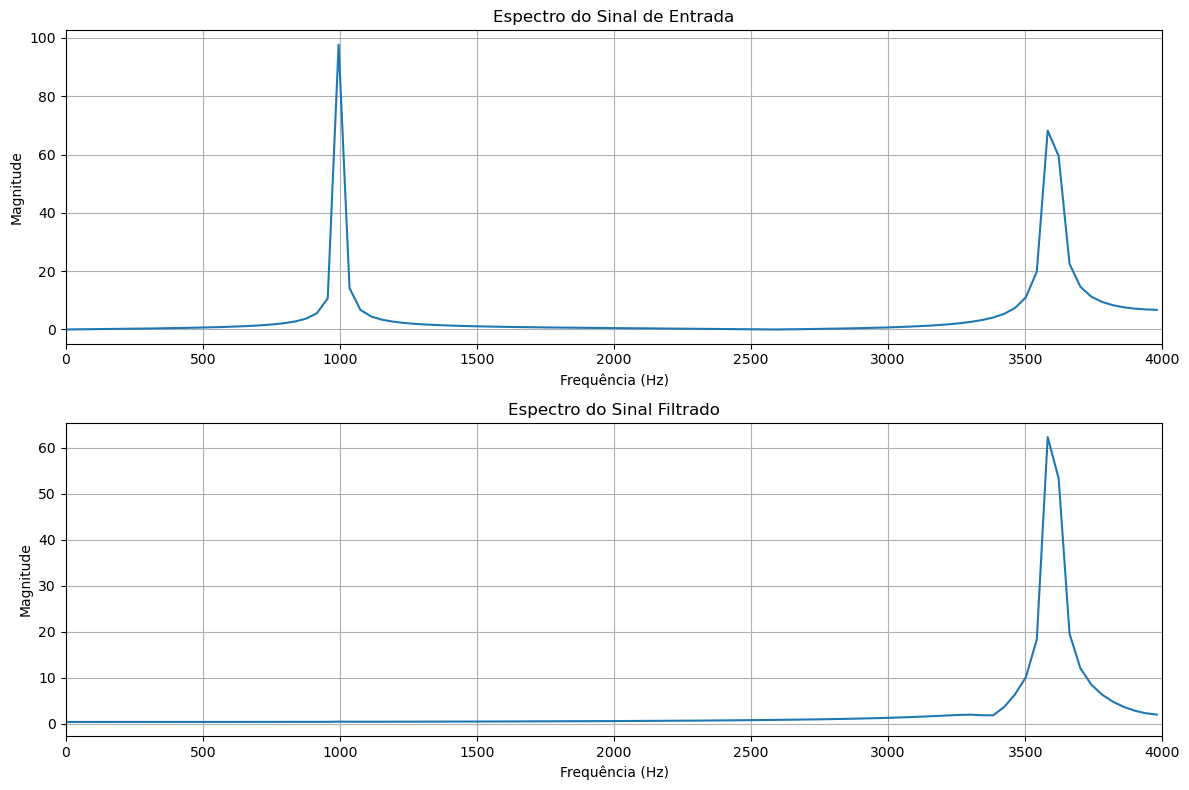


O teste com senoides
demonstrou que o
filtro atenuou
fortemente a
componente de
1000 Hz, preservando
a componente de
3600 Hz localizada
na banda passante.

Comparando-se com
os demais filtros
analisados, o filtro
elíptico apresentou
a menor ordem entre
todos os projetos.

Entretanto, observou-se
fase fortemente não
linear e atraso de
grupo variável,
características típicas
de filtros IIR
altamente seletivos.


In [9]:
# =========================================================
# IIR Elíptico
# =========================================================

# =========================================================
# Especificações
# =========================================================

fs = 8000

fp = 3400
fsb = 2800

Rp = 1      # dB
As = 50     # dB

# =========================================================
# Frequências digitais normalizadas
# =========================================================

Wp = fp/(fs/2)

Ws = fsb/(fs/2)

print("Wp =", Wp)

print("Ws =", Ws)

# =========================================================
# Projeto do filtro
# =========================================================

N_ellip, Wn_ellip = signal.ellipord(
    wp=Wp,
    ws=Ws,
    gpass=Rp,
    gstop=As
)

print("Ordem do filtro:",
      N_ellip)

print("Frequência crítica:",
      Wn_ellip)

b_ellip, a_ellip = signal.ellip(
    N_ellip,
    Rp,
    As,
    Wn_ellip,
    btype='high'
)

# =========================================================
# Número de multiplicações
# =========================================================

# Em cascata de segunda ordem:
#
# cada seção biquadrática utiliza:
#
# 5 multiplicações no numerador
# 4 multiplicações no denominador
#
# total:
#
# 9 multiplicações por seção

num_sections = int(np.ceil(N_ellip/2))

mult_ellip = 9*num_sections

print("Número de seções biquadráticas:",
      num_sections)

print("Número de multiplicações por amostra:",
      mult_ellip)

# =========================================================
# Lista de coeficientes
# =========================================================

print("\nCoeficientes do numerador:")

print(b_ellip)

print("\nCoeficientes do denominador:")

print(a_ellip)

# =========================================================
# Resposta em frequência
# =========================================================

db, mag, pha, grd, w = freqz_m(
    b_ellip,
    a_ellip
)

f = w*fs/(2*np.pi)

# =========================================================
# Verificação das especificações
# =========================================================

idx_stop = np.where(f <= 2800)

As_real = -np.max(db[idx_stop])

idx_pass = np.where(
    (f >= 3400) &
    (f <= 3900)
)

Rp_real = (
    np.max(db[idx_pass])
    -
    np.min(db[idx_pass])
)

print("\nAtenuação obtida:",
      As_real,
      "dB")

print("Ripple obtido:",
      Rp_real,
      "dB")

# =========================================================
# Resposta de fase
# =========================================================

pha_unwrap = np.unwrap(pha)

print("\nO filtro IIR elíptico")
print("apresentou fase não")
print("linear, característica")
print("típica de filtros")
print("recursivos altamente")
print("seletivos.")

# =========================================================
# Atraso de grupo
# =========================================================

idx_gd = np.where(
    (f >= 3400) &
    (f <= 3900)
)

print("\nAtraso médio de grupo:",
      np.mean(grd),
      "amostras")

print("\nO atraso de grupo não")
print("permaneceu constante")
print("ao longo da banda")
print("passante, indicando")
print("distorção de fase no")
print("sinal filtrado.")

# =========================================================
# Gráficos principais
# =========================================================

fig, axs = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12,8)
)

# ---------------------------------------------------------
# Magnitude linear
# ---------------------------------------------------------

axs[0,0].plot(f, mag)

axs[0,0].axvline(
    2800,
    color='r',
    linestyle='--'
)

axs[0,0].axvline(
    3400,
    color='r',
    linestyle='--'
)

axs[0,0].set_ylim(0,1.1)

axs[0,0].set_title(
    'Resposta em Magnitude'
)

axs[0,0].set_xlabel(
    'Frequência (Hz)'
)

axs[0,0].set_ylabel('|H|')

axs[0,0].grid()

# ---------------------------------------------------------
# Magnitude em dB
# ---------------------------------------------------------

axs[0,1].plot(f, db)

axs[0,1].axhline(
    -Rp,
    color='r',
    linestyle='--'
)

axs[0,1].axhline(
    -As,
    color='r',
    linestyle='--'
)

axs[0,1].axvline(
    2800,
    color='r',
    linestyle='--'
)

axs[0,1].axvline(
    3400,
    color='r',
    linestyle='--'
)

axs[0,1].set_title(
    'Resposta em Magnitude (dB)'
)

axs[0,1].set_xlabel(
    'Frequência (Hz)'
)

axs[0,1].set_ylabel('dB')

axs[0,1].grid()

# ---------------------------------------------------------
# Fase
# ---------------------------------------------------------

axs[1,0].plot(f, pha_unwrap)

axs[1,0].set_title(
    'Resposta de Fase'
)

axs[1,0].set_xlabel(
    'Frequência (Hz)'
)

axs[1,0].set_ylabel('rad')

axs[1,0].grid()

# ---------------------------------------------------------
# Atraso de grupo
# ---------------------------------------------------------

axs[1,1].plot(f, grd)

axs[1,1].ticklabel_format(
    style='plain',
    axis='y',
    useOffset=False
)

axs[1,1].set_title(
    'Atraso de Grupo'
)

axs[1,1].set_xlabel(
    'Frequência (Hz)'
)

axs[1,1].set_ylabel(
    'Amostras'
)

axs[1,1].grid()

fig.tight_layout()

plt.show()

print("\nO filtro elíptico apresentou")
print("picos elevados de atraso")
print("de grupo próximos à banda")
print("de transição, característica")
print("associada à elevada")
print("seletividade espectral.")

# =========================================================
# Resposta ao impulso
# =========================================================

delta, n = impseq(0,0,120)

h = signal.lfilter(
    b_ellip,
    a_ellip,
    delta
)

plt.figure(figsize=(10,4))

plt.stem(n, h)

plt.title(
    'Resposta ao Impulso'
)

plt.xlabel('n')

plt.ylabel('h[n]')

plt.grid()

plt.show()

print("\nA resposta ao impulso")
print("apresentou comportamento")
print("oscilatório com")
print("decaimento ao longo")
print("do tempo, característica")
print("típica de filtros IIR.")

print("\nComparando-se com o")
print("filtro Chebyshev II,")
print("o filtro elíptico")
print("apresentou oscilações")
print("mais pronunciadas na")
print("resposta ao impulso.")

print("\nAssim como nos demais")
print("filtros IIR, a resposta")
print("ao impulso possui")
print("duração teoricamente")
print("infinita.")

# =========================================================
# Polos e zeros
# =========================================================

plt.figure(figsize=(6,6))

zplane(
    b_ellip,
    a_ellip
)

plt.title(
    'Diagrama de Polos e Zeros'
)

plt.show()

print("\nOs polos permaneceram")
print("internos ao círculo")
print("unitário, garantindo")
print("estabilidade do filtro.")

print("\nOs zeros distribuíram-se")
print("muito próximos ao")
print("círculo unitário,")
print("característica típica")
print("de filtros elípticos")
print("altamente seletivos.")

print("\nComparando-se com o")
print("filtro Chebyshev II,")
print("observou-se maior")
print("seletividade espectral")
print("com menor ordem, porém")
print("à custa de maior")
print("não linearidade de")
print("fase.")

# =========================================================
# Teste do filtro com senoides
# =========================================================

# ---------------------------------------------------------
# eixo temporal
# ---------------------------------------------------------

n = discrete_time_range(0,200)

# ---------------------------------------------------------
# frequências
# ---------------------------------------------------------

f1 = 1000
f2 = 3600

w1 = analog_to_digital_frequency(
    f1,
    fs
)

w2 = analog_to_digital_frequency(
    f2,
    fs
)

# ---------------------------------------------------------
# sinais
# ---------------------------------------------------------

x1 = sine(1, w1, n)

x2 = sine(1, w2, n)

# sinal composto

x = x1 + x2

# ---------------------------------------------------------
# filtragem
# ---------------------------------------------------------

y = apply_filter(
    b_ellip,
    a_ellip,
    x
)

# =========================================================
# Sinais no tempo
# =========================================================

plt.figure(figsize=(12,8))

# ---------------------------------------------------------
# entrada
# ---------------------------------------------------------

plt.subplot(2,1,1)

plt.plot(n, x)

plt.title(
    'Sinal de Entrada'
)

plt.xlabel('n')

plt.ylabel('Amplitude')

plt.grid()

# ---------------------------------------------------------
# saída
# ---------------------------------------------------------

plt.subplot(2,1,2)

plt.plot(n, y)

plt.title(
    'Sinal Filtrado'
)

plt.xlabel('n')

plt.ylabel('Amplitude')

plt.grid()

plt.tight_layout()

plt.show()

# =========================================================
# Espectros
# =========================================================

f_in, X = fft_spectrum(x, fs)

f_out, Y = fft_spectrum(y, fs)

plt.figure(figsize=(12,8))

# ---------------------------------------------------------
# espectro entrada
# ---------------------------------------------------------

plt.subplot(2,1,1)

plt.plot(f_in, X)

plt.xlim(0,4000)

plt.title(
    'Espectro do Sinal de Entrada'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Magnitude'
)

plt.grid()

# ---------------------------------------------------------
# espectro saída
# ---------------------------------------------------------

plt.subplot(2,1,2)

plt.plot(f_out, Y)

plt.xlim(0,4000)

plt.title(
    'Espectro do Sinal Filtrado'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Magnitude'
)

plt.grid()

plt.tight_layout()

plt.show()

print("\nO teste com senoides")
print("demonstrou que o")
print("filtro atenuou")
print("fortemente a")
print("componente de")
print("1000 Hz, preservando")
print("a componente de")
print("3600 Hz localizada")
print("na banda passante.")

print("\nComparando-se com")
print("os demais filtros")
print("analisados, o filtro")
print("elíptico apresentou")
print("a menor ordem entre")
print("todos os projetos.")

print("\nEntretanto, observou-se")
print("fase fortemente não")
print("linear e atraso de")
print("grupo variável,")
print("características típicas")
print("de filtros IIR")
print("altamente seletivos.")

# =========================================================
# Salvando métricas
# =========================================================

Rp_real_ellip = Rp_real

As_real_ellip = As_real

gd_ellip = np.mean(
    grd[idx_gd]
)

Coeficientes quantizados - 16 bits:
[ 0.00088501 -0.00111389  0.00035095  0.00164795 -0.00410461  0.00531006
 -0.00340271 -0.00224304  0.00979614 -0.01509094  0.01327515 -0.0018158
 -0.01681519  0.03442383 -0.03938293  0.02148438  0.02270508 -0.08656311
  0.15423584 -0.2059021   0.22521973 -0.2059021   0.15423584 -0.08656311
  0.02270508  0.02148438 -0.03938293  0.03442383 -0.01681519 -0.0018158
  0.01327515 -0.01509094  0.00979614 -0.00224304 -0.00340271  0.00531006
 -0.00410461  0.00164795  0.00035095 -0.00111389  0.00088501]

Coeficientes quantizados - 8 bits:
[ 0.         -0.          0.          0.         -0.00390625  0.00390625
 -0.00390625 -0.00390625  0.01171875 -0.015625    0.01171875 -0.
 -0.015625    0.03515625 -0.0390625   0.0234375   0.0234375  -0.0859375
  0.15234375 -0.20703125  0.2265625  -0.20703125  0.15234375 -0.0859375
  0.0234375   0.0234375  -0.0390625   0.03515625 -0.015625   -0.
  0.01171875 -0.015625    0.01171875 -0.00390625 -0.00390625  0.00390625
 -0.003906

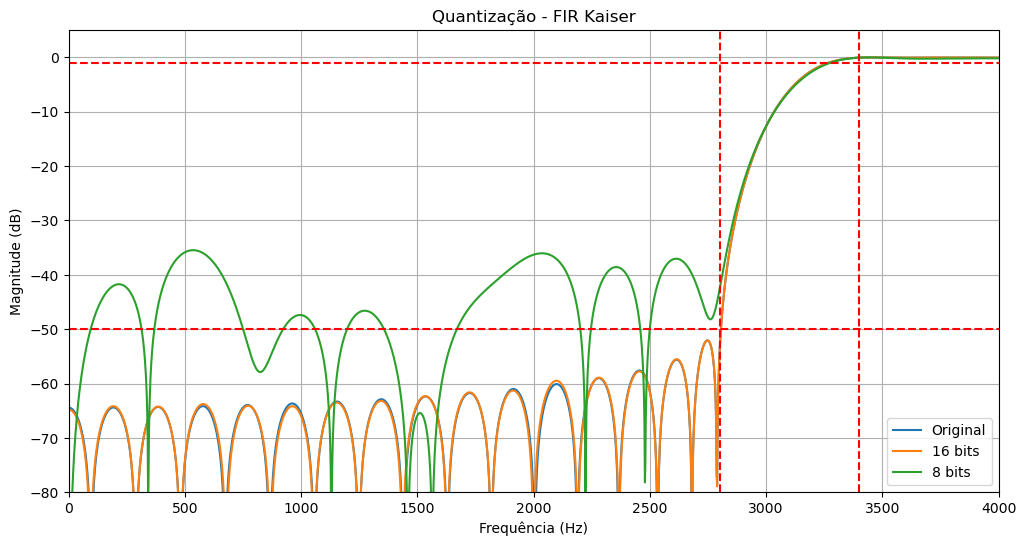

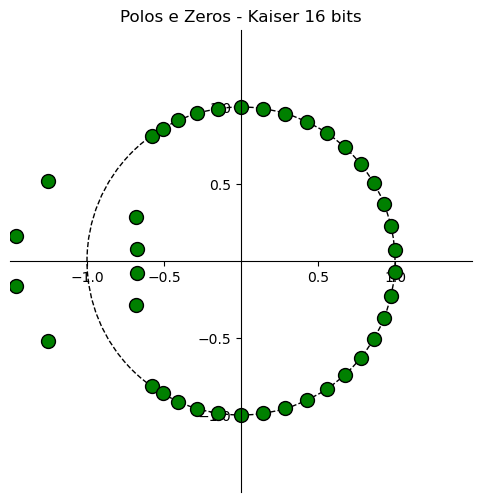

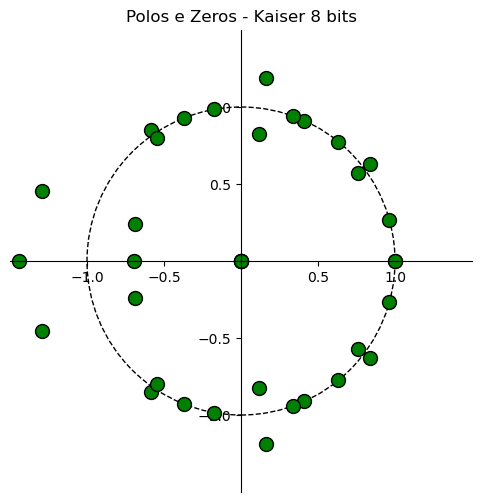

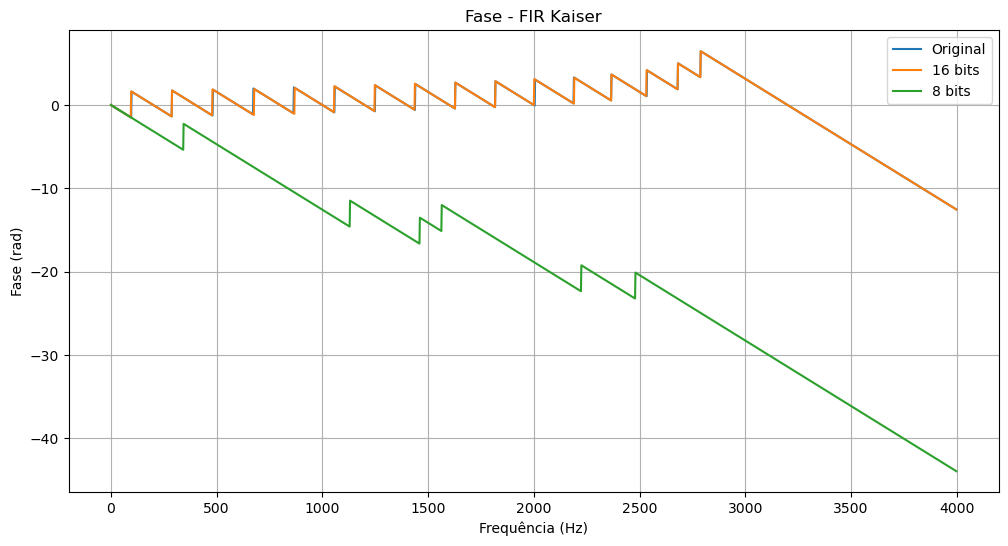


A quantização em 16 bits
preservou praticamente
inalterada a resposta
de fase do filtro.

Já a quantização em
8 bits introduziu
deformações significativas
na resposta de fase,
comprometendo a
linearidade originalmente
presente no filtro FIR.

A degradação observada
ocorreu devido à perda
de precisão dos
coeficientes, reduzindo
a simetria necessária
para fase linear em
filtros FIR.

A quantização em 16 bits
produziu alterações muito
pequenas na resposta em
frequência do filtro.

Os polos e zeros permaneceram
praticamente inalterados,
indicando boa robustez
numérica.

Já a quantização em 8 bits
introduziu alterações
significativas nos
coeficientes.

Diversos coeficientes
pequenos foram arredondados
para zero, degradando
a seletividade espectral
do filtro.

Observou-se redução da
atenuação na banda de
rejeição e maior desvio
em relação ao projeto
original.


In [10]:
# =========================================================
# Quantização - FIR Kaiser
# =========================================================

# =========================================================
# Quantização dos coeficientes
# =========================================================

b_kaiser_q16, L16, B16 = QCoeff(
    b_kaiser,
    16
)

b_kaiser_q8, L8, B8 = QCoeff(
    b_kaiser,
    8
)

print("Coeficientes quantizados - 16 bits:")

print(b_kaiser_q16)

print("\nCoeficientes quantizados - 8 bits:")

print(b_kaiser_q8)

# =========================================================
# Respostas em frequência
# =========================================================

w, H_orig = signal.freqz(
    b_kaiser,
    a_kaiser,
    worN=2048
)

w, H_q16 = signal.freqz(
    b_kaiser_q16,
    a_kaiser,
    worN=2048
)

w, H_q8 = signal.freqz(
    b_kaiser_q8,
    a_kaiser,
    worN=2048
)

# ---------------------------------------------------------
# Magnitude em dB
# ---------------------------------------------------------

eps = np.spacing(1)

db_orig = 20*np.log10(
    np.abs(H_orig)/np.max(np.abs(H_orig))
    + eps
)

db_q16 = 20*np.log10(
    np.abs(H_q16)/np.max(np.abs(H_q16))
)

db_q8 = 20*np.log10(
    np.abs(H_q8)/np.max(np.abs(H_q8))
)

# ---------------------------------------------------------
# eixo frequência
# ---------------------------------------------------------

f = w*fs/(2*np.pi)

# =========================================================
# Comparação das respostas
# =========================================================

plt.figure(figsize=(12,6))

plt.plot(
    f,
    db_orig,
    label='Original'
)

plt.plot(
    f,
    db_q16,
    label='16 bits'
)

plt.plot(
    f,
    db_q8,
    label='8 bits'
)

# ---------------------------------------------------------
# especificações
# ---------------------------------------------------------

plt.axhline(
    -Rp,
    color='r',
    linestyle='--'
)

plt.axhline(
    -As,
    color='r',
    linestyle='--'
)

plt.axvline(
    2800,
    color='r',
    linestyle='--'
)

plt.axvline(
    3400,
    color='r',
    linestyle='--'
)

# ---------------------------------------------------------
# gráficos
# ---------------------------------------------------------

plt.xlim(0,4000)

plt.ylim(-80,5)

plt.title(
    'Quantização - FIR Kaiser'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Magnitude (dB)'
)

plt.grid()

plt.legend()

plt.show()

# =========================================================
# Polos e zeros
# =========================================================

# ---------------------------------------------------------
# 16 bits
# ---------------------------------------------------------

plt.figure(figsize=(6,6))

zplane(
    b_kaiser_q16,
    a_kaiser
)

plt.title(
    'Polos e Zeros - Kaiser 16 bits'
)

plt.show()

# ---------------------------------------------------------
# 8 bits
# ---------------------------------------------------------

plt.figure(figsize=(6,6))

zplane(
    b_kaiser_q8,
    a_kaiser
)

plt.title(
    'Polos e Zeros - Kaiser 8 bits'
)

plt.show()

# =========================================================
# Resposta de fase
# =========================================================

pha_orig = np.unwrap(
    np.angle(H_orig)
)

pha_q16 = np.unwrap(
    np.angle(H_q16)
)

pha_q8 = np.unwrap(
    np.angle(H_q8)
)

plt.figure(figsize=(12,6))

plt.plot(
    f,
    pha_orig,
    label='Original'
)

plt.plot(
    f,
    pha_q16,
    label='16 bits'
)

plt.plot(
    f,
    pha_q8,
    label='8 bits'
)

plt.title(
    'Fase - FIR Kaiser'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Fase (rad)'
)

plt.grid()

plt.legend()

plt.show()

# =========================================================
# Discussão da fase
# =========================================================

print("\nA quantização em 16 bits")
print("preservou praticamente")
print("inalterada a resposta")
print("de fase do filtro.")

print("\nJá a quantização em")
print("8 bits introduziu")
print("deformações significativas")
print("na resposta de fase,")
print("comprometendo a")
print("linearidade originalmente")
print("presente no filtro FIR.")

print("\nA degradação observada")
print("ocorreu devido à perda")
print("de precisão dos")
print("coeficientes, reduzindo")
print("a simetria necessária")
print("para fase linear em")
print("filtros FIR.")

# =========================================================
# Discussão
# =========================================================

print("\nA quantização em 16 bits")
print("produziu alterações muito")
print("pequenas na resposta em")
print("frequência do filtro.")

print("\nOs polos e zeros permaneceram")
print("praticamente inalterados,")
print("indicando boa robustez")
print("numérica.")

print("\nJá a quantização em 8 bits")
print("introduziu alterações")
print("significativas nos")
print("coeficientes.")

print("\nDiversos coeficientes")
print("pequenos foram arredondados")
print("para zero, degradando")
print("a seletividade espectral")
print("do filtro.")

print("\nObservou-se redução da")
print("atenuação na banda de")
print("rejeição e maior desvio")
print("em relação ao projeto")
print("original.")

Coeficientes quantizados - 16 bits:
[ 0.00126648 -0.00108337  0.00028992  0.00126648 -0.00317383  0.00421143
 -0.0027771  -0.00189209  0.00852966 -0.01348877  0.012146   -0.00169373
 -0.01593018  0.0330658  -0.03825378  0.02105713  0.0223999  -0.08583069
  0.1534729  -0.20530701  0.22471619 -0.20530701  0.1534729  -0.08583069
  0.0223999   0.02105713 -0.03825378  0.0330658  -0.01593018 -0.00169373
  0.012146   -0.01348877  0.00852966 -0.00189209 -0.0027771   0.00421143
 -0.00317383  0.00126648  0.00028992 -0.00108337  0.00126648]

Coeficientes quantizados - 8 bits:
[ 0.         -0.          0.          0.         -0.00390625  0.00390625
 -0.00390625 -0.          0.0078125  -0.01171875  0.01171875 -0.
 -0.015625    0.03125    -0.0390625   0.01953125  0.0234375  -0.0859375
  0.15234375 -0.20703125  0.2265625  -0.20703125  0.15234375 -0.0859375
  0.0234375   0.01953125 -0.0390625   0.03125    -0.015625   -0.
  0.01171875 -0.01171875  0.0078125  -0.         -0.00390625  0.00390625
 -0.0039

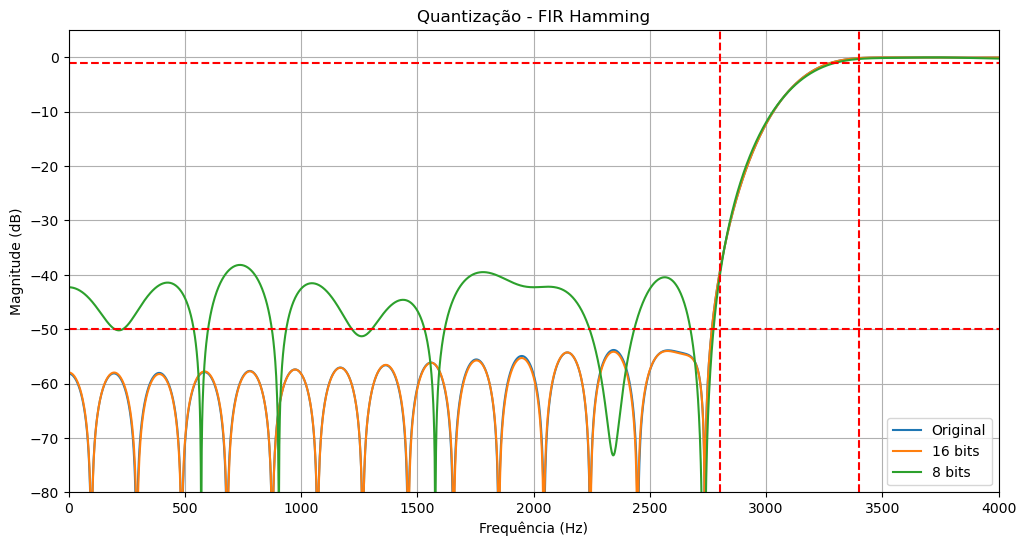

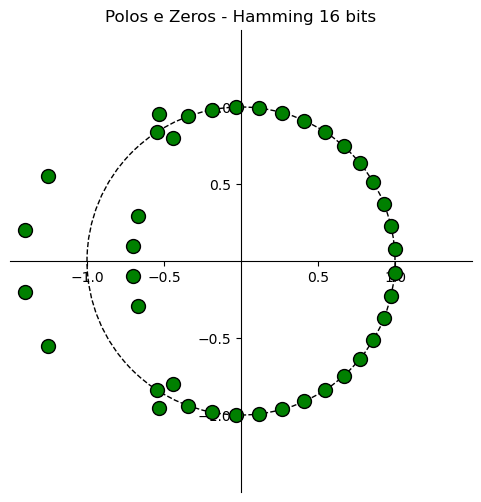

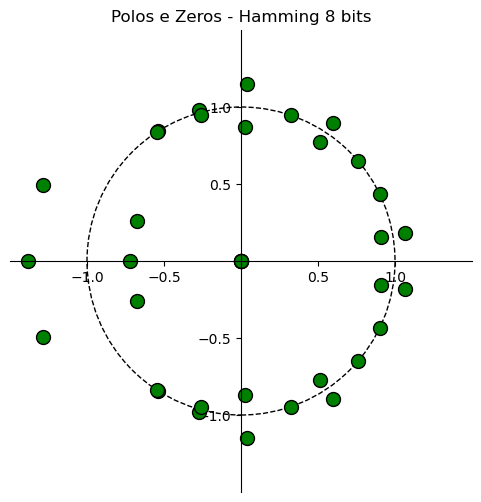

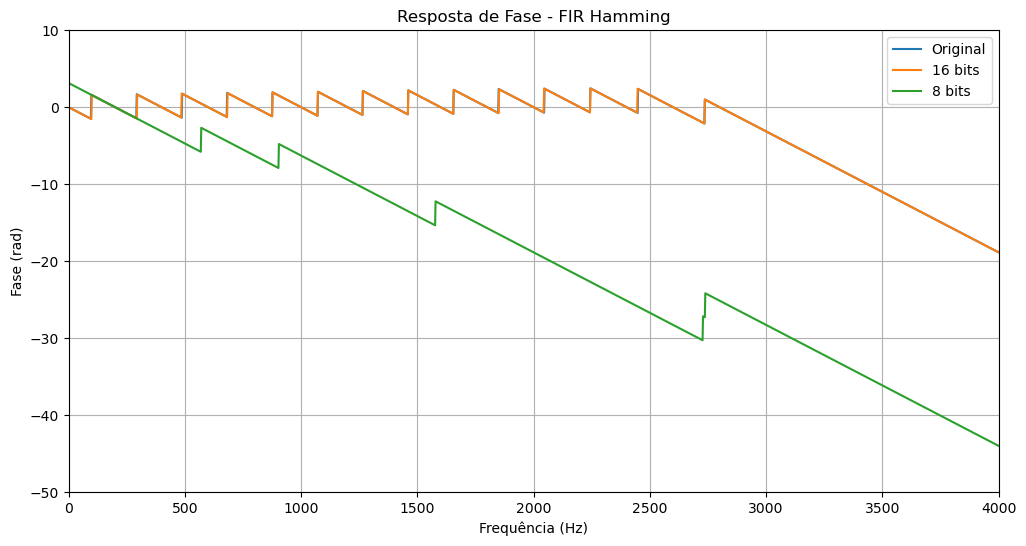


A quantização em 16 bits
preservou praticamente
inalterada a resposta
de fase do filtro.

Já a quantização em
8 bits introduziu
deformações significativas
na resposta de fase,
comprometendo a
linearidade originalmente
presente no filtro FIR.

A degradação observada
ocorreu devido à perda
de precisão dos
coeficientes, reduzindo
a simetria necessária
para fase linear em
filtros FIR.

A quantização em 16 bits
produziu alterações muito
pequenas na resposta em
frequência do filtro.

Os polos e zeros permaneceram
praticamente inalterados,
indicando boa robustez
numérica.

Já a quantização em 8 bits
introduziu alterações
significativas nos
coeficientes.

Diversos coeficientes
pequenos foram arredondados
para zero, degradando
a seletividade espectral
do filtro.

Observou-se redução da
atenuação na banda de
rejeição e maior desvio
em relação ao projeto
original.

Observou-se que o filtro
FIR projetado pela
janela de Hamming também
apresentou degradação
significativa sob
quantização em 8 bits.


In [11]:
# =========================================================
# Quantização - FIR Hamming
# =========================================================

# =========================================================
# Quantização dos coeficientes
# =========================================================

b_hamming_q16, L16, B16 = QCoeff(
    b_hamming,
    16
)

b_hamming_q8, L8, B8 = QCoeff(
    b_hamming,
    8
)

print("Coeficientes quantizados - 16 bits:")

print(b_hamming_q16)

print("\nCoeficientes quantizados - 8 bits:")

print(b_hamming_q8)

# =========================================================
# Respostas em frequência
# =========================================================

w, H_orig = signal.freqz(
    b_hamming,
    a_hamming,
    worN=2048
)

w, H_q16 = signal.freqz(
    b_hamming_q16,
    a_hamming,
    worN=2048
)

w, H_q8 = signal.freqz(
    b_hamming_q8,
    a_hamming,
    worN=2048
)

# ---------------------------------------------------------
# Magnitude em dB
# ---------------------------------------------------------

eps = np.spacing(1)

db_orig = 20*np.log10(
    np.abs(H_orig)/np.max(np.abs(H_orig))
    + eps
)

db_q16 = 20*np.log10(
    np.abs(H_q16)/np.max(np.abs(H_q16))
    + eps
)

db_q8 = 20*np.log10(
    np.abs(H_q8)/np.max(np.abs(H_q8))
    + eps
)

# ---------------------------------------------------------
# eixo frequência
# ---------------------------------------------------------

f = w*fs/(2*np.pi)

# =========================================================
# Comparação das respostas
# =========================================================

plt.figure(figsize=(12,6))

plt.plot(
    f,
    db_orig,
    label='Original'
)

plt.plot(
    f,
    db_q16,
    label='16 bits'
)

plt.plot(
    f,
    db_q8,
    label='8 bits'
)

# ---------------------------------------------------------
# especificações
# ---------------------------------------------------------

plt.axhline(
    -Rp,
    color='r',
    linestyle='--'
)

plt.axhline(
    -As,
    color='r',
    linestyle='--'
)

plt.axvline(
    2800,
    color='r',
    linestyle='--'
)

plt.axvline(
    3400,
    color='r',
    linestyle='--'
)

# ---------------------------------------------------------
# gráficos
# ---------------------------------------------------------

plt.xlim(0,4000)

plt.ylim(-80,5)

plt.title(
    'Quantização - FIR Hamming'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Magnitude (dB)'
)

plt.grid()

plt.legend()

plt.show()

# =========================================================
# Polos e zeros
# =========================================================

# ---------------------------------------------------------
# 16 bits
# ---------------------------------------------------------

plt.figure(figsize=(6,6))

zplane(
    b_hamming_q16,
    a_hamming
)

plt.title(
    'Polos e Zeros - Hamming 16 bits'
)

plt.show()

# ---------------------------------------------------------
# 8 bits
# ---------------------------------------------------------

plt.figure(figsize=(6,6))

zplane(
    b_hamming_q8,
    a_hamming
)

plt.title(
    'Polos e Zeros - Hamming 8 bits'
)

plt.show()

# =========================================================
# Resposta de fase
# =========================================================

pha_orig = np.unwrap(
    np.angle(H_orig)
)

pha_q16 = np.unwrap(
    np.angle(H_q16)
)

pha_q8 = np.unwrap(
    np.angle(H_q8)
)

plt.figure(figsize=(12,6))

plt.plot(
    f,
    pha_orig,
    label='Original'
)

plt.plot(
    f,
    pha_q16,
    label='16 bits'
)

plt.plot(
    f,
    pha_q8,
    label='8 bits'
)

plt.xlim(0,4000)

plt.ylim(-50,10)

plt.title(
    'Resposta de Fase - FIR Hamming'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Fase (rad)'
)

plt.grid()

plt.legend()

plt.show()

# =========================================================
# Discussão da fase
# =========================================================

print("\nA quantização em 16 bits")
print("preservou praticamente")
print("inalterada a resposta")
print("de fase do filtro.")

print("\nJá a quantização em")
print("8 bits introduziu")
print("deformações significativas")
print("na resposta de fase,")
print("comprometendo a")
print("linearidade originalmente")
print("presente no filtro FIR.")

print("\nA degradação observada")
print("ocorreu devido à perda")
print("de precisão dos")
print("coeficientes, reduzindo")
print("a simetria necessária")
print("para fase linear em")
print("filtros FIR.")

# =========================================================
# Discussão
# =========================================================

print("\nA quantização em 16 bits")
print("produziu alterações muito")
print("pequenas na resposta em")
print("frequência do filtro.")

print("\nOs polos e zeros permaneceram")
print("praticamente inalterados,")
print("indicando boa robustez")
print("numérica.")

print("\nJá a quantização em 8 bits")
print("introduziu alterações")
print("significativas nos")
print("coeficientes.")

print("\nDiversos coeficientes")
print("pequenos foram arredondados")
print("para zero, degradando")
print("a seletividade espectral")
print("do filtro.")

print("\nObservou-se redução da")
print("atenuação na banda de")
print("rejeição e maior desvio")
print("em relação ao projeto")
print("original.")

print("\nObservou-se que o filtro")
print("FIR projetado pela")
print("janela de Hamming também")
print("apresentou degradação")
print("significativa sob")
print("quantização em 8 bits.")

Seções biquadráticas:
[[ 0.00662986 -0.00621231  0.00662986  1.          1.03700721  0.28355925]
 [ 1.          0.91934042  1.          1.          1.26444425  0.49965481]
 [ 1.          1.33785376  1.          1.          1.5726621   0.81292619]]

SOS quantizada - 16 bits:
[[ 0.00662231 -0.00622559  0.00662231  1.          1.03701782  0.28356934]
 [ 1.          0.91934204  1.          1.          1.26443481  0.49966431]
 [ 1.          1.33786011  1.          1.          1.57266235  0.81292725]]

SOS quantizada - 8 bits:
[[ 0.0078125 -0.0078125  0.0078125  1.         1.0390625  0.28125  ]
 [ 1.         0.921875   1.         1.         1.265625   0.5      ]
 [ 1.         1.3359375  1.         1.         1.5703125  0.8125   ]]


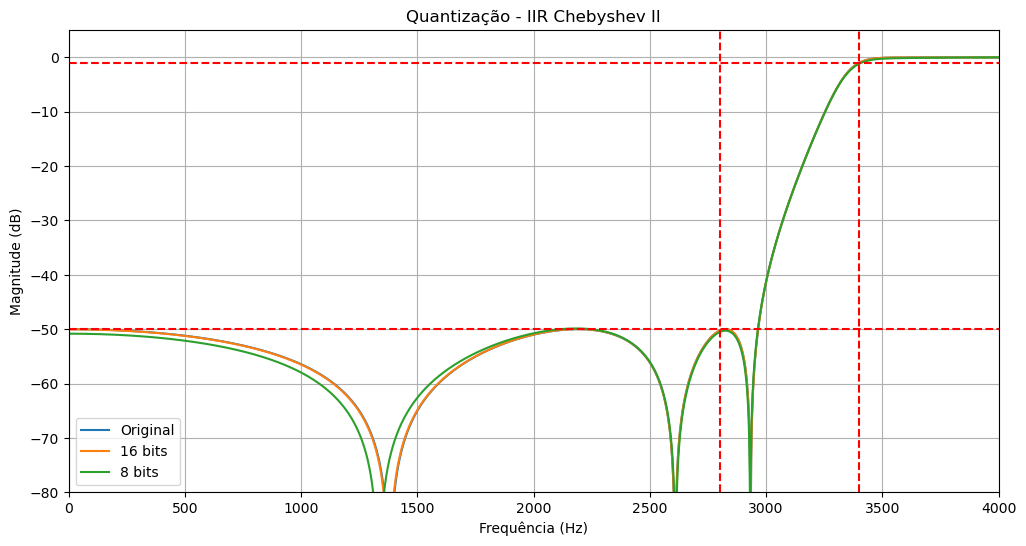

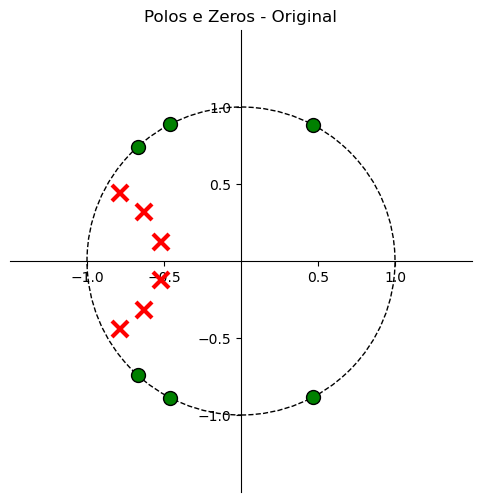

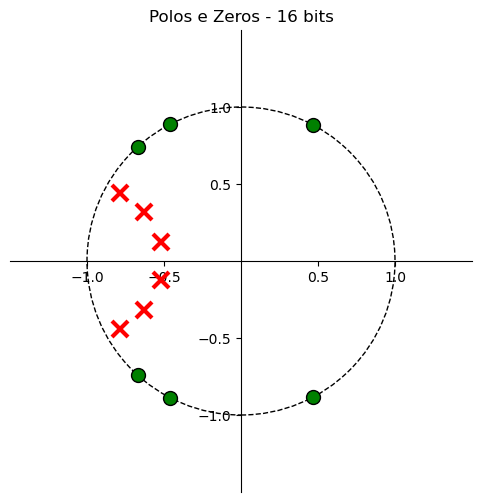

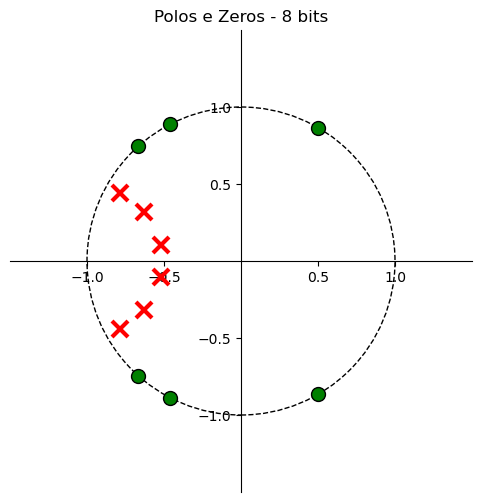

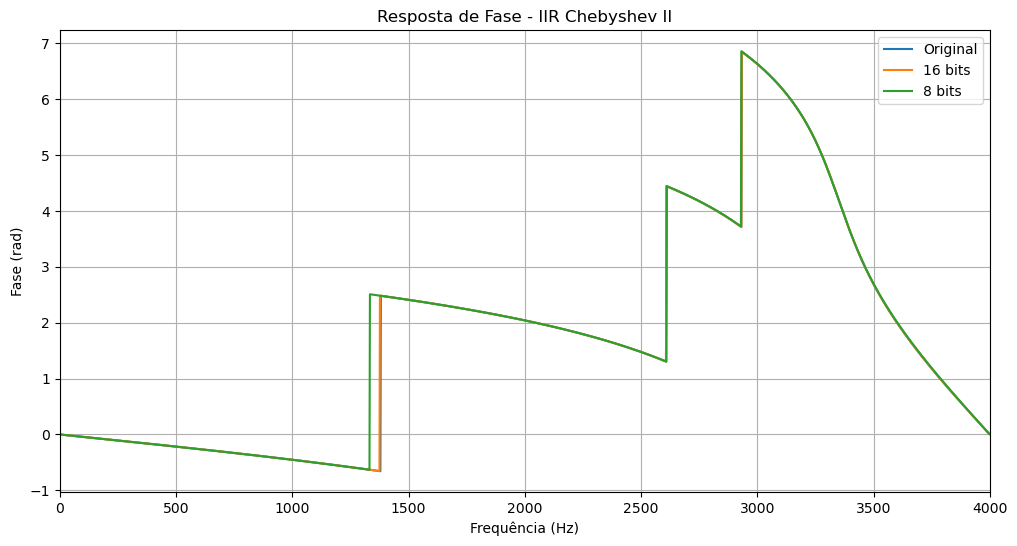


Mesmo na quantização
em 8 bits, o filtro
manteve resposta em
frequência bastante
próxima ao projeto
original.

A implementação em
cascata de segunda
ordem contribuiu
para maior robustez
numérica frente
à quantização.

As alterações mais
visíveis ocorreram
nas regiões de
transição e nos
mínimos de rejeição,
porém sem comprometer
a estabilidade do
filtro.

Os polos permaneceram
internos ao círculo
unitário mesmo após
a quantização,
garantindo estabilidade
do sistema.

Comparando-se com os
filtros FIR analisados
anteriormente, observou-se
menor degradação da
resposta em frequência
para 8 bits.

Esse comportamento
ocorreu principalmente
devido à menor ordem
do filtro IIR e ao
uso de implementação
em seções biquadráticas.

A quantização produziu
pequenos deslocamentos
dos polos e zeros,
porém insuficientes
para provocar
instabilidade ou
alterações severas
na resposta espectral.

Observou-se também
que a resposta de
fase permaneceu muito
próxima da original,
indicando baixa
sensibilidade da

In [12]:
# =========================================================
# Quantização - IIR Chebyshev II
# =========================================================

# =========================================================
# Conversão para SOS
# =========================================================

sos_cheb2 = signal.tf2sos(
    b_cheb2,
    a_cheb2
)

print("Seções biquadráticas:")

print(sos_cheb2)

# =========================================================
# Quantização das seções
# =========================================================

sos_cheb2_q16, L16, B16 = QCoeff(
    sos_cheb2,
    16
)

sos_cheb2_q8, L8, B8 = QCoeff(
    sos_cheb2,
    8
)

print("\nSOS quantizada - 16 bits:")

print(sos_cheb2_q16)

print("\nSOS quantizada - 8 bits:")

print(sos_cheb2_q8)

# =========================================================
# Conversão para forma de transferência
# (somente para análise visual)
# =========================================================

b_cheb2_q16, a_cheb2_q16 = signal.sos2tf(
    sos_cheb2_q16
)

b_cheb2_q8, a_cheb2_q8 = signal.sos2tf(
    sos_cheb2_q8
)

# =========================================================
# Respostas em frequência
# =========================================================

w, H_orig = signal.sosfreqz(
    sos_cheb2,
    worN=2048
)

w, H_q16 = signal.sosfreqz(
    sos_cheb2_q16,
    worN=2048
)

w, H_q8 = signal.sosfreqz(
    sos_cheb2_q8,
    worN=2048
)

# ---------------------------------------------------------
# Magnitude em dB
# ---------------------------------------------------------

eps = np.spacing(1)

db_orig = 20*np.log10(
    np.abs(H_orig)/np.max(np.abs(H_orig))
    + eps
)

db_q16 = 20*np.log10(
    np.abs(H_q16)/np.max(np.abs(H_q16))
    + eps
)

db_q8 = 20*np.log10(
    np.abs(H_q8)/np.max(np.abs(H_q8))
    + eps
)

# ---------------------------------------------------------
# eixo frequência
# ---------------------------------------------------------

f = w*fs/(2*np.pi)

# =========================================================
# Comparação das respostas
# =========================================================

plt.figure(figsize=(12,6))

plt.plot(
    f,
    db_orig,
    label='Original'
)

plt.plot(
    f,
    db_q16,
    label='16 bits'
)

plt.plot(
    f,
    db_q8,
    label='8 bits'
)

# ---------------------------------------------------------
# especificações
# ---------------------------------------------------------

plt.axhline(
    -Rp,
    color='r',
    linestyle='--'
)

plt.axhline(
    -As,
    color='r',
    linestyle='--'
)

plt.axvline(
    2800,
    color='r',
    linestyle='--'
)

plt.axvline(
    3400,
    color='r',
    linestyle='--'
)

# ---------------------------------------------------------
# gráficos
# ---------------------------------------------------------

plt.xlim(0,4000)

plt.ylim(-80,5)

plt.title(
    'Quantização - IIR Chebyshev II'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Magnitude (dB)'
)

plt.grid()

plt.legend()

plt.show()

# =========================================================
# Polos e zeros
# =========================================================

# ---------------------------------------------------------
# Original
# ---------------------------------------------------------

plt.figure(figsize=(6,6))

zplane(
    b_cheb2,
    a_cheb2
)

plt.title(
    'Polos e Zeros - Original'
)

plt.show()

# ---------------------------------------------------------
# 16 bits
# ---------------------------------------------------------

plt.figure(figsize=(6,6))

zplane(
    b_cheb2_q16,
    a_cheb2_q16
)

plt.title(
    'Polos e Zeros - 16 bits'
)

plt.show()

# ---------------------------------------------------------
# 8 bits
# ---------------------------------------------------------

plt.figure(figsize=(6,6))

zplane(
    b_cheb2_q8,
    a_cheb2_q8
)

plt.title(
    'Polos e Zeros - 8 bits'
)

plt.show()

# =========================================================
# Resposta de fase
# =========================================================

pha_orig = np.unwrap(
    np.angle(H_orig)
)

pha_q16 = np.unwrap(
    np.angle(H_q16)
)

pha_q8 = np.unwrap(
    np.angle(H_q8)
)

plt.figure(figsize=(12,6))

plt.plot(
    f,
    pha_orig,
    label='Original'
)

plt.plot(
    f,
    pha_q16,
    label='16 bits'
)

plt.plot(
    f,
    pha_q8,
    label='8 bits'
)

plt.xlim(0,4000)

plt.title(
    'Resposta de Fase - IIR Chebyshev II'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Fase (rad)'
)

plt.grid()

plt.legend()

plt.show()

# =========================================================
# Discussão 
# =========================================================

print("\nMesmo na quantização")
print("em 8 bits, o filtro")
print("manteve resposta em")
print("frequência bastante")
print("próxima ao projeto")
print("original.")

print("\nA implementação em")
print("cascata de segunda")
print("ordem contribuiu")
print("para maior robustez")
print("numérica frente")
print("à quantização.")

print("\nAs alterações mais")
print("visíveis ocorreram")
print("nas regiões de")
print("transição e nos")
print("mínimos de rejeição,")
print("porém sem comprometer")
print("a estabilidade do")
print("filtro.")

print("\nOs polos permaneceram")
print("internos ao círculo")
print("unitário mesmo após")
print("a quantização,")
print("garantindo estabilidade")
print("do sistema.")

print("\nComparando-se com os")
print("filtros FIR analisados")
print("anteriormente, observou-se")
print("menor degradação da")
print("resposta em frequência")
print("para 8 bits.")

print("\nEsse comportamento")
print("ocorreu principalmente")
print("devido à menor ordem")
print("do filtro IIR e ao")
print("uso de implementação")
print("em seções biquadráticas.")

print("\nA quantização produziu")
print("pequenos deslocamentos")
print("dos polos e zeros,")
print("porém insuficientes")
print("para provocar")
print("instabilidade ou")
print("alterações severas")
print("na resposta espectral.")

print("\nObservou-se também")
print("que a resposta de")
print("fase permaneceu muito")
print("próxima da original,")
print("indicando baixa")
print("sensibilidade da")
print("estrutura utilizada")
print("aos erros de")
print("quantização.")

Seções biquadráticas:
[[ 6.67642781e-03 -1.50484917e-03  6.67642781e-03  1.00000000e+00
   1.65190520e+00  7.14784280e-01]
 [ 1.00000000e+00  1.22459371e+00  1.00000000e+00  1.00000000e+00
   1.69147907e+00  8.97056224e-01]]

SOS quantizada - 16 bits:
[[ 6.68334961e-03 -1.49536133e-03  6.68334961e-03  1.00000000e+00
   1.65191650e+00  7.14782715e-01]
 [ 1.00000000e+00  1.22457886e+00  1.00000000e+00  1.00000000e+00
   1.69146729e+00  8.97064209e-01]]

SOS quantizada - 8 bits:
[[ 0.0078125 -0.         0.0078125  1.         1.6484375  0.7109375]
 [ 1.         1.2265625  1.         1.         1.6953125  0.8984375]]


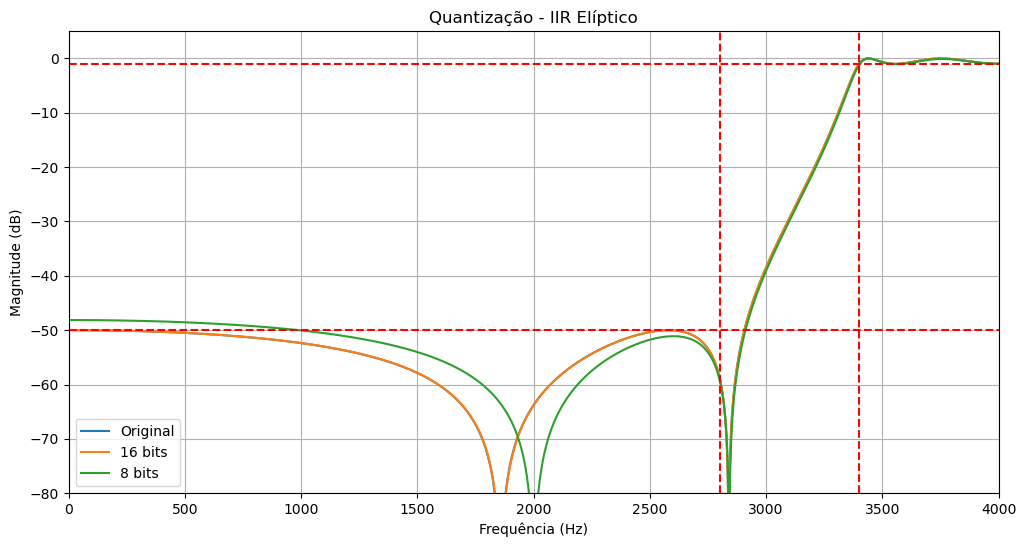

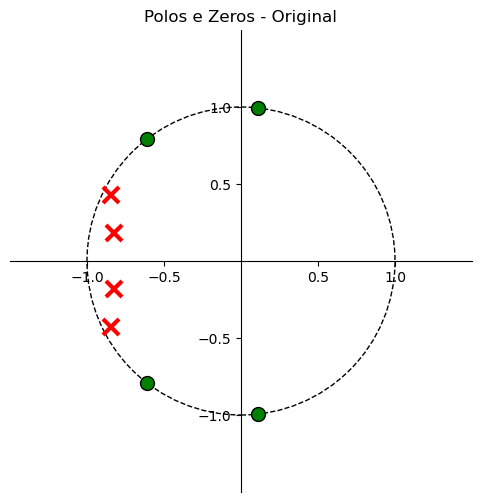

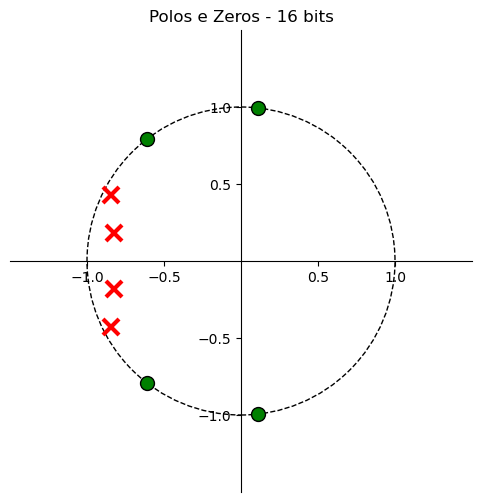

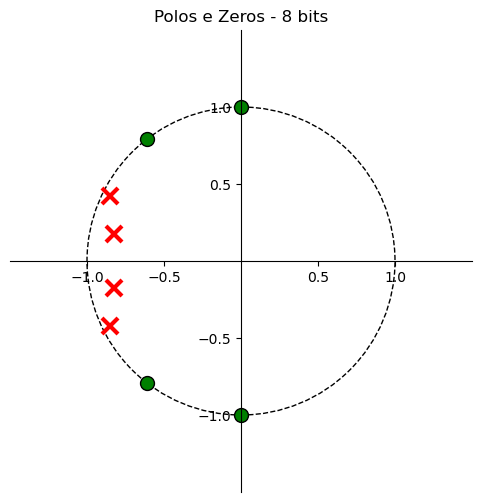

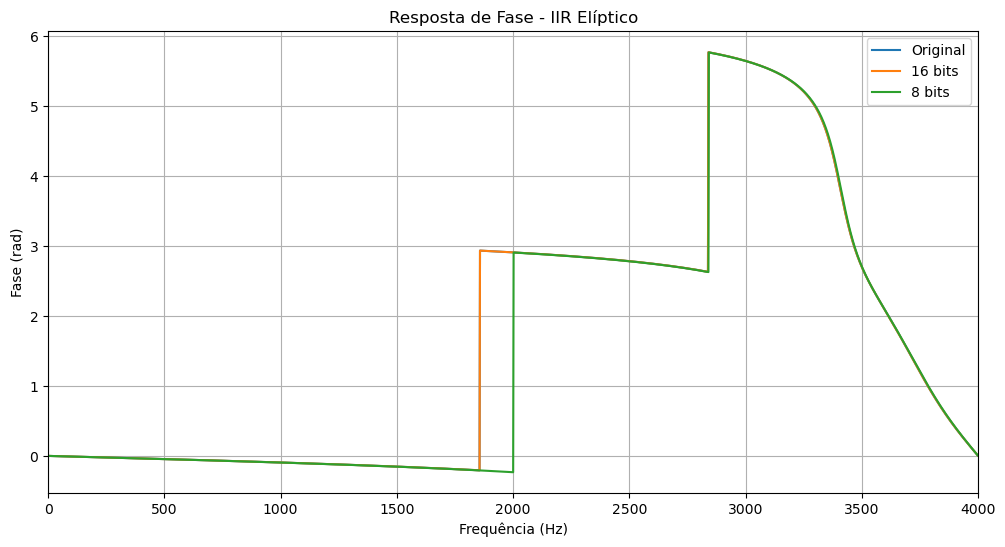


A quantização em 16 bits
preservou praticamente
inalterada a resposta
de fase do filtro.

Mesmo em 8 bits,
a resposta de fase
permaneceu próxima
à original, embora
com pequenas
deformações próximas
à banda de rejeição.

Filtros IIR elípticos
apresentam elevada
seletividade, tornando
a análise da fase
particularmente
importante.

Mesmo na quantização
em 8 bits, o filtro
manteve resposta em
frequência bastante
próxima ao projeto
original.

A implementação em
cascata de segunda
ordem contribuiu
para maior robustez
numérica frente
à quantização.

As alterações mais
visíveis ocorreram
nas regiões de
mínimos de rejeição,
porém sem comprometer
a estabilidade do
filtro.

Os polos permaneceram
internos ao círculo
unitário mesmo após
a quantização,
garantindo estabilidade
do sistema.

Comparando-se com os
filtros FIR analisados
anteriormente, observou-se
menor degradação da
resposta em frequência
para 8 bits.

Esse comportamento
ocorreu principalmente
devido à menor ordem
do filtro IIR e ao
uso

In [13]:
# =========================================================
# Quantização - IIR Elíptico
# =========================================================

# =========================================================
# Conversão para SOS
# =========================================================

sos_ellip = signal.tf2sos(
    b_ellip,
    a_ellip
)

print("Seções biquadráticas:")

print(sos_ellip)

# =========================================================
# Quantização das seções
# =========================================================

sos_ellip_q16, L16, B16 = QCoeff(
    sos_ellip,
    16
)

sos_ellip_q8, L8, B8 = QCoeff(
    sos_ellip,
    8
)

print("\nSOS quantizada - 16 bits:")

print(sos_ellip_q16)

print("\nSOS quantizada - 8 bits:")

print(sos_ellip_q8)

# =========================================================
# Conversão para forma de transferência
# (somente para análise visual)
# =========================================================

b_ellip_q16, a_ellip_q16 = signal.sos2tf(
    sos_ellip_q16
)

b_ellip_q8, a_ellip_q8 = signal.sos2tf(
    sos_ellip_q8
)

# =========================================================
# Respostas em frequência
# =========================================================

w, H_orig = signal.sosfreqz(
    sos_ellip,
    worN=2048
)

w, H_q16 = signal.sosfreqz(
    sos_ellip_q16,
    worN=2048
)

w, H_q8 = signal.sosfreqz(
    sos_ellip_q8,
    worN=2048
)

# ---------------------------------------------------------
# Magnitude em dB
# ---------------------------------------------------------

eps = np.spacing(1)

db_orig = 20*np.log10(
    np.abs(H_orig)/np.max(np.abs(H_orig))
    + eps
)

db_q16 = 20*np.log10(
    np.abs(H_q16)/np.max(np.abs(H_q16))
    + eps
)

db_q8 = 20*np.log10(
    np.abs(H_q8)/np.max(np.abs(H_q8))
    + eps
)

# ---------------------------------------------------------
# eixo frequência
# ---------------------------------------------------------

f = w*fs/(2*np.pi)

# =========================================================
# Comparação das respostas
# =========================================================

plt.figure(figsize=(12,6))

plt.plot(
    f,
    db_orig,
    label='Original'
)

plt.plot(
    f,
    db_q16,
    label='16 bits'
)

plt.plot(
    f,
    db_q8,
    label='8 bits'
)

# ---------------------------------------------------------
# especificações
# ---------------------------------------------------------

plt.axhline(
    -Rp,
    color='r',
    linestyle='--'
)

plt.axhline(
    -As,
    color='r',
    linestyle='--'
)

plt.axvline(
    2800,
    color='r',
    linestyle='--'
)

plt.axvline(
    3400,
    color='r',
    linestyle='--'
)

# ---------------------------------------------------------
# gráficos
# ---------------------------------------------------------

plt.xlim(0,4000)

plt.ylim(-80,5)

plt.title(
    'Quantização - IIR Elíptico'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Magnitude (dB)'
)

plt.grid()

plt.legend()

plt.show()

# =========================================================
# Polos e zeros
# =========================================================

# ---------------------------------------------------------
# Original
# ---------------------------------------------------------

plt.figure(figsize=(6,6))

zplane(
    b_ellip,
    a_ellip
)

plt.title(
    'Polos e Zeros - Original'
)

plt.show()

# ---------------------------------------------------------
# 16 bits
# ---------------------------------------------------------

plt.figure(figsize=(6,6))

zplane(
    b_ellip_q16,
    a_ellip_q16
)

plt.title(
    'Polos e Zeros - 16 bits'
)

plt.show()

# ---------------------------------------------------------
# 8 bits
# ---------------------------------------------------------

plt.figure(figsize=(6,6))

zplane(
    b_ellip_q8,
    a_ellip_q8
)

plt.title(
    'Polos e Zeros - 8 bits'
)

plt.show()

# =========================================================
# Resposta de fase
# =========================================================

pha_orig = np.unwrap(
    np.angle(H_orig)
)

pha_q16 = np.unwrap(
    np.angle(H_q16)
)

pha_q8 = np.unwrap(
    np.angle(H_q8)
)

plt.figure(figsize=(12,6))

plt.plot(
    f,
    pha_orig,
    label='Original'
)

plt.plot(
    f,
    pha_q16,
    label='16 bits'
)

plt.plot(
    f,
    pha_q8,
    label='8 bits'
)

plt.xlim(0,4000)

plt.title(
    'Resposta de Fase - IIR Elíptico'
)

plt.xlabel(
    'Frequência (Hz)'
)

plt.ylabel(
    'Fase (rad)'
)

plt.grid()

plt.legend()

plt.show()

# =========================================================
# Discussão da fase
# =========================================================

print("\nA quantização em 16 bits")
print("preservou praticamente")
print("inalterada a resposta")
print("de fase do filtro.")

print("\nMesmo em 8 bits,")
print("a resposta de fase")
print("permaneceu próxima")
print("à original, embora")
print("com pequenas")
print("deformações próximas")
print("à banda de rejeição.")

print("\nFiltros IIR elípticos")
print("apresentam elevada")
print("seletividade, tornando")
print("a análise da fase")
print("particularmente")
print("importante.")

# =========================================================
# Discussão 
# =========================================================

print("\nMesmo na quantização")
print("em 8 bits, o filtro")
print("manteve resposta em")
print("frequência bastante")
print("próxima ao projeto")
print("original.")

print("\nA implementação em")
print("cascata de segunda")
print("ordem contribuiu")
print("para maior robustez")
print("numérica frente")
print("à quantização.")

print("\nAs alterações mais")
print("visíveis ocorreram")
print("nas regiões de")
print("mínimos de rejeição,")
print("porém sem comprometer")
print("a estabilidade do")
print("filtro.")

print("\nOs polos permaneceram")
print("internos ao círculo")
print("unitário mesmo após")
print("a quantização,")
print("garantindo estabilidade")
print("do sistema.")

print("\nComparando-se com os")
print("filtros FIR analisados")
print("anteriormente, observou-se")
print("menor degradação da")
print("resposta em frequência")
print("para 8 bits.")

print("\nEsse comportamento")
print("ocorreu principalmente")
print("devido à menor ordem")
print("do filtro IIR e ao")
print("uso de implementação")
print("em seções biquadráticas.")

print("\nA quantização produziu")
print("pequenos deslocamentos")
print("dos polos e zeros,")
print("porém insuficientes")
print("para provocar")
print("instabilidade ou")
print("alterações severas")
print("na resposta espectral.")

In [14]:
# =========================================================
# Conclusão
# =========================================================

print("\nOs filtros FIR apresentaram")
print("fase aproximadamente linear")
print("e atraso de grupo constante,")
print("características desejáveis")
print("em aplicações sensíveis à")
print("distorção de fase.")

print("\nEntretanto, os filtros FIR")
print("necessitaram ordens mais")
print("elevadas e maior número")
print("de multiplicações por")
print("amostra.")

print("\nO filtro FIR com janela")
print("de Kaiser apresentou")
print("melhor desempenho espectral")
print("entre os FIR analisados,")
print("atingindo atenuação superior")
print("a 50 dB.")

print("\nJá o filtro FIR com")
print("janela de Hamming não")
print("atingiu completamente a")
print("atenuação especificada,")
print("apresentando aproximadamente")
print("40 dB na banda de rejeição.")

print("\nOs filtros IIR apresentaram")
print("ordens significativamente")
print("menores, reduzindo o custo")
print("computacional da implementação.")

print("\nO filtro Chebyshev II")
print("atingiu as especificações")
print("com ordem 6, enquanto")
print("o filtro elíptico obteve")
print("desempenho semelhante com")
print("apenas ordem 4.")

print("\nO filtro elíptico apresentou")
print("a maior seletividade entre")
print("todos os projetos analisados,")
print("porém com maior não")
print("linearidade de fase.")

print("\nA análise de quantização")
print("mostrou que os filtros FIR")
print("foram mais sensíveis à")
print("redução de precisão dos")
print("coeficientes, especialmente")
print("na representação em 8 bits.")

print("\nNos filtros IIR implementados")
print("em cascata de segunda ordem,")
print("a quantização apresentou")
print("impacto significativamente")
print("menor, preservando a")
print("estabilidade e a resposta")
print("em frequência.")

print("\nConclui-se que filtros FIR")
print("são mais adequados quando")
print("fase linear é prioritária,")
print("enquanto filtros IIR são")
print("mais eficientes quando")
print("se deseja maior seletividade")
print("com menor custo computacional.")

# =========================================================
# Resumo numérico
# =========================================================

print("\n====================================")
print("RESUMO DOS FILTROS")
print("====================================")

print("===== FIR KAISER =====")

print("Ordem:", N_kaiser - 1)

print("Multiplicações:",
      N_kaiser)

print("Atraso médio:",
      gd_kaiser)

print("Ripple:",
      Rp_real_kaiser)

print("Atenuação:",
      As_real_kaiser)

print()

print("===== FIR HAMMING =====")

print("Ordem:", N_hamming - 1)

print("Multiplicações:",
      N_hamming)

print("Atraso médio:",
      gd_hamming)

print("Ripple:",
      Rp_real_hamming)

print("Atenuação:",
      As_real_hamming)

print()

print("===== IIR CHEBYSHEV II =====")

print("Ordem:", N_cheb2)

print("Multiplicações:",
      mult_cheb2)

print("Atraso médio:",
      gd_cheb2)

print("Ripple:",
      Rp_real_cheb2)

print("Atenuação:",
      As_real_cheb2)

print()

print("===== IIR ELÍPTICO =====")

print("Ordem:", N_ellip)

print("Multiplicações:",
      mult_ellip)

print("Atraso médio:",
      gd_ellip)

print("Ripple:",
      Rp_real_ellip)

print("Atenuação:",
      As_real_ellip)


Os filtros FIR apresentaram
fase aproximadamente linear
e atraso de grupo constante,
características desejáveis
em aplicações sensíveis à
distorção de fase.

Entretanto, os filtros FIR
necessitaram ordens mais
elevadas e maior número
de multiplicações por
amostra.

O filtro FIR com janela
de Kaiser apresentou
melhor desempenho espectral
entre os FIR analisados,
atingindo atenuação superior
a 50 dB.

Já o filtro FIR com
janela de Hamming não
atingiu completamente a
atenuação especificada,
apresentando aproximadamente
40 dB na banda de rejeição.

Os filtros IIR apresentaram
ordens significativamente
menores, reduzindo o custo
computacional da implementação.

O filtro Chebyshev II
atingiu as especificações
com ordem 6, enquanto
o filtro elíptico obteve
desempenho semelhante com
apenas ordem 4.

O filtro elíptico apresentou
a maior seletividade entre
todos os projetos analisados,
porém com maior não
linearidade de fase.

A análise de quantização
mostrou que os filtros FIR
foram mais sensí